# 02 Temporal EDA — Anas Workstream 4

Family-specific EDA: temporal parameter identifiability, alternative decoder comparison, crossed case×time backtests, and forecast validation.

In [1]:
%pip install pandas numpy pyarrow scipy scikit-learn matplotlib seaborn -q


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /Users/tengkuanas/Projects/mwap-exdw-surrogate-model/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import sys
import importlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.special import expit, logit
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA

# Resolve paths dynamically: works locally in VS Code or in Databricks
_curr = Path.cwd().resolve()
REPO_ROOT = None
temp = _curr
while temp != temp.parent:
    if (temp / "Anas").exists() and (temp / "data").exists():
        REPO_ROOT = temp
        break
    temp = temp.parent

if REPO_ROOT is not None:
    ANAS = REPO_ROOT / "Anas"
    SHARED = REPO_ROOT / "data" / "shared"
else:
    ANAS = Path(
        "/Workspace/Users/tengkuanas.zainalabi@petronas.com.my/"
        "mwap-exdw-surrogate-model/Anas-db"
    )
    SHARED = Path(
        "/Workspace/Users/tengkuanas.zainalabi@petronas.com.my/MWAP/data"
    )
DATA = ANAS / "data"
OUT = ANAS / "outputs"
FIG = OUT / "figures"
TABLE = OUT / "tables"

for path in [FIG, TABLE]:
    path.mkdir(parents=True, exist_ok=True)

if not (ANAS / "temporal_utils.py").exists():
    raise FileNotFoundError("Run Anas's 01 Data Preparation.ipynb first.")

sys.path.insert(0, str(ANAS))
import temporal_utils as tu
importlib.reload(tu)

unc, curves = tu.load_shared(SHARED)
PARAMS = tu.PARAMS

targets = pd.read_parquet(DATA / "temporal_targets.parquet")
fits = pd.read_parquet(DATA / "temporal_fits.parquet")
trials = pd.read_parquet(DATA / "temporal_fit_trials.parquet")
history = pd.read_parquet(DATA / "cutoff_history.parquet")
truth = pd.read_parquet(DATA / "forecast_truth.parquet")
folds = pd.read_parquet(DATA / "case_folds.parquet").set_index("case_num")

for frame in [targets, fits, trials, history, truth]:
    frame["cutoff"] = pd.to_datetime(frame["cutoff"])
for frame in [history, truth]:
    frame["date"] = pd.to_datetime(frame["date"])

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "pdf.fonttype": 42,
})

def show_save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight", dpi=300)
    fig.savefig(FIG / f"{name}.pdf", bbox_inches="tight")
    display(fig)
    plt.close(fig)

def save_table(frame, name):
    frame.to_csv(TABLE / f"{name}.csv", index=False)
    display(frame)

def poly_model():
    return make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=2, include_bias=False),
        StandardScaler(),
        Ridge(alpha=1.0),
    )

def fit_parameter_map(fit_targets, method):
    X = unc.loc[fit_targets["case_num"], PARAMS].to_numpy(float)
    z = tu.encode_targets(fit_targets, method)
    target_scaler = StandardScaler().fit(z)
    estimator = poly_model().fit(X, target_scaler.transform(z))
    return estimator, target_scaler

def predict_parameter_map(estimator, scaler, case_numbers, method):
    X = unc.loc[list(case_numbers), PARAMS].to_numpy(float)
    z = scaler.inverse_transform(estimator.predict(X))
    return tu.decode_targets(z, method)

print("Forecast methods:", tu.METHODS)
print("No test production labels loaded.")
print("Figures:", FIG)
print("Tables:", TABLE)

Production rows: 5725536
Excluded invalid date/value rows: 5637420


Forecast methods: ['Constant', 'Separate', 'Liquid-WC-time', 'Liquid-WC-volume']
No test production labels loaded.
Figures: /Users/tengkuanas/Projects/mwap-exdw-surrogate-model/Anas/outputs/figures
Tables: /Users/tengkuanas/Projects/mwap-exdw-surrogate-model/Anas/outputs/tables


,cutoff,D_oil_median,D_oil_std,D_oil_min,D_oil_max,D_liquid_median,D_liquid_std,D_liquid_min,D_liquid_max,water_plateau_median,...,water_k_min,water_k_max,beta_time_median,beta_time_std,beta_time_min,beta_time_max,beta_volume_median,beta_volume_std,beta_volume_min,beta_volume_max
0,2003-01-01,0.088376,0.044330,0.040744,0.186616,0.000000,0.000798,0.000000,0.006672,24938.114014,...,0.071166,0.133068,0.892604,0.069754,0.736282,1.027958,1.428654,0.104243,1.204643,1.644204
1,2004-01-01,0.177918,0.024192,0.133072,0.220533,0.048140,0.006762,0.048101,0.068915,7711.908802,...,0.113960,1.006164,0.508593,0.032471,0.429056,0.539391,0.837632,0.045449,0.726916,0.890371
2,2005-01-01,0.204348,0.014077,0.184011,0.244557,0.078700,0.005840,0.075583,0.091461,7073.723917,...,0.042234,1.316417,0.367330,0.041490,0.296345,0.422506,0.648817,0.065097,0.546143,0.747351
3,2008-01-01,0.134546,0.020212,0.098041,0.164931,0.020519,0.003967,0.011566,0.026567,16194.791696,...,0.013558,0.283723,0.199415,0.015359,0.173694,0.224776,0.421914,0.041654,0.361768,0.505078


,cutoff,water_plateau_bound_fraction,water_k_bound_fraction,liquid_decline_zero_fraction,maximum_cutoff_age_days
0,2003-01-01,0.928571,0.0,0.971429,0.0
1,2004-01-01,0.000000,0.0,0.000000,0.0
2,2005-01-01,0.100000,0.0,0.000000,0.0
3,2008-01-01,0.400000,0.0,0.000000,0.0


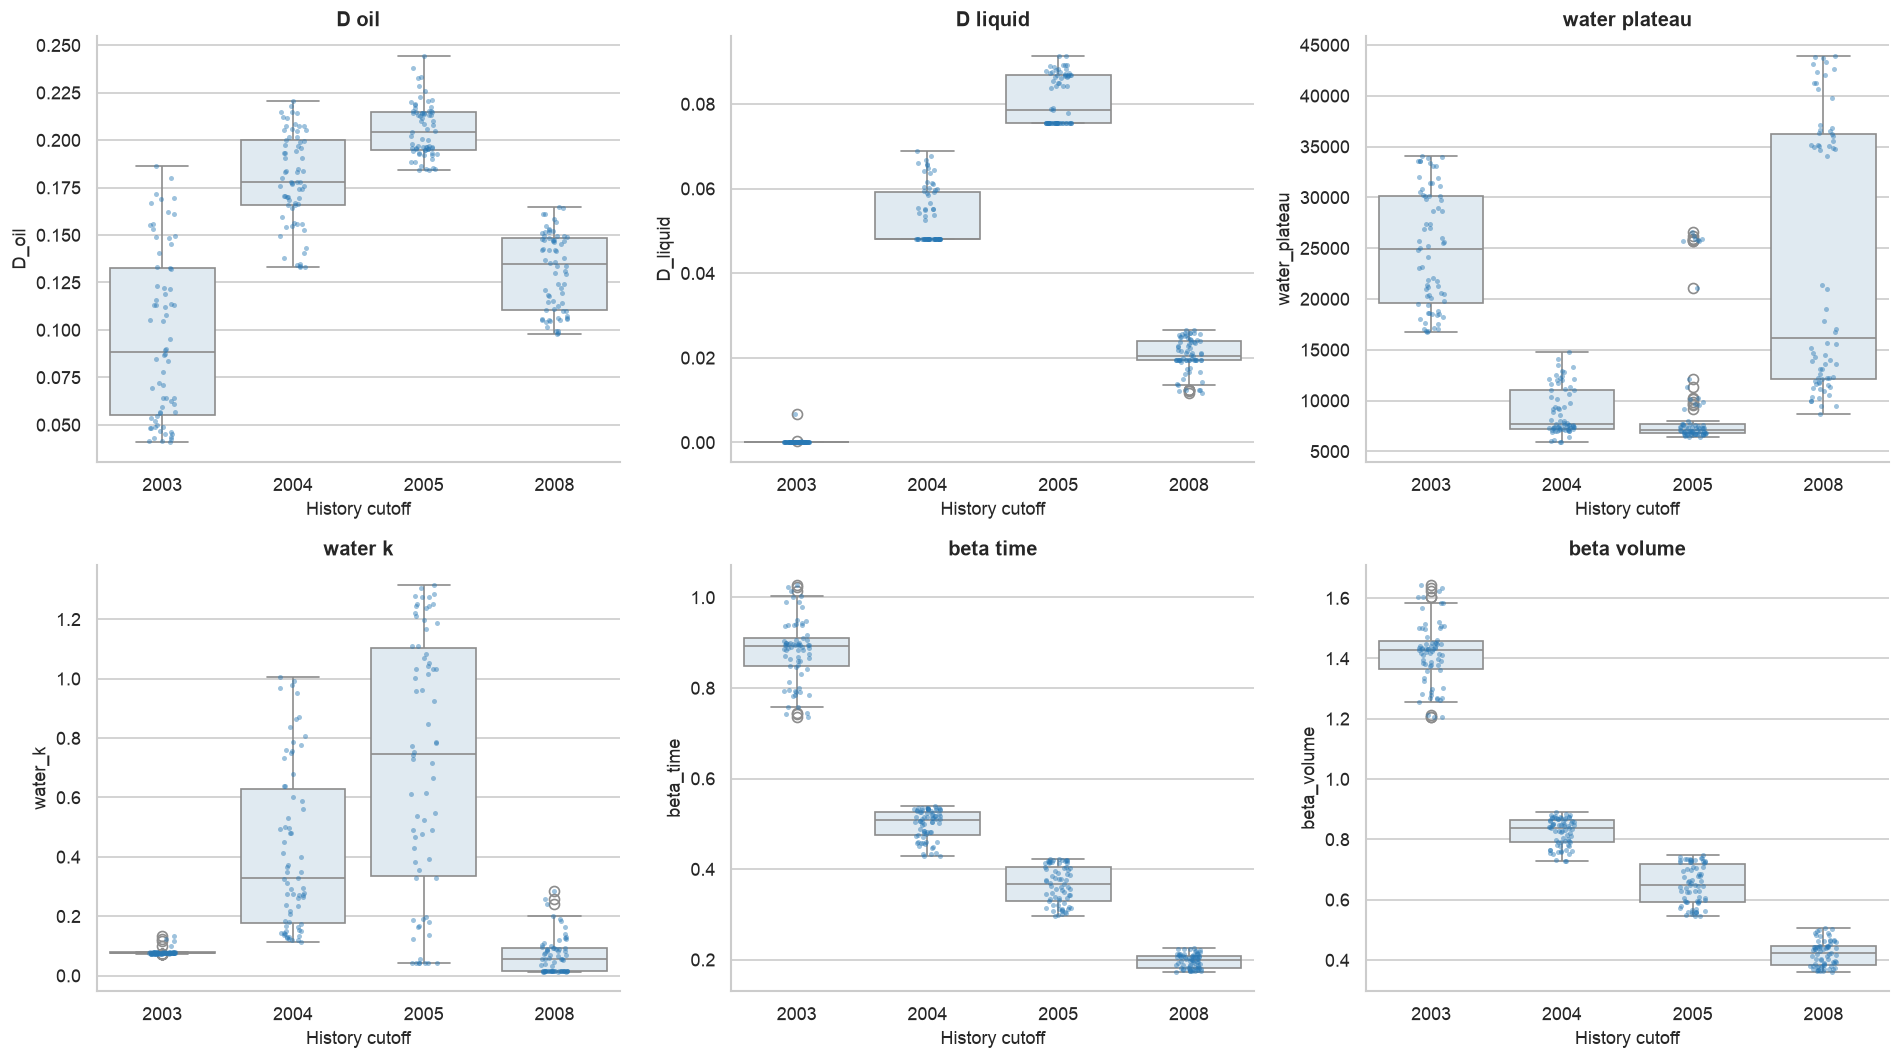

In [3]:
TRAIN = targets.loc[targets["case_num"] <= 70].copy()
PARAMETER_COLUMNS = [
    "D_oil", "D_liquid", "water_plateau",
    "water_k", "beta_time", "beta_volume",
]

distribution = TRAIN.groupby("cutoff")[PARAMETER_COLUMNS].agg(
    ["median", "std", "min", "max"]
)
distribution.columns = [
    f"{parameter}_{statistic}"
    for parameter, statistic in distribution.columns
]
save_table(distribution.reset_index(), "01_temporal_parameter_distribution")

bound_report = TRAIN.groupby("cutoff").agg(
    water_plateau_bound_fraction=("water_ratio_near_bound", "mean"),
    water_k_bound_fraction=("water_k_near_bound", "mean"),
    liquid_decline_zero_fraction=("D_liquid_at_zero", "mean"),
    maximum_cutoff_age_days=("max_cutoff_observation_age_days", "max"),
).reset_index()
save_table(bound_report, "01_parameter_boundary_report")

plot_frame = TRAIN.assign(
    origin=TRAIN["cutoff"].dt.strftime("%Y")
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, column in zip(axes.flat, PARAMETER_COLUMNS):
    sns.boxplot(
        data=plot_frame, x="origin", y=column,
        color="#DDEAF4", ax=ax,
    )
    sns.stripplot(
        data=plot_frame, x="origin", y=column,
        color="#2878B5", alpha=0.45, size=3, ax=ax,
    )
    ax.set_title(column.replace("_", " "))
    ax.set_xlabel("History cutoff")
    ax.set_ylabel(column)
show_save(fig, "01_temporal_parameter_distributions")

,cutoff,parameter,median_relative_window_range,p90_relative_window_range
0,2003-01-01,D_liquid,0.000000e+00,0.000000e+00
1,2003-01-01,D_oil,1.966961e-01,2.605171e-01
2,2003-01-01,beta_time,5.676590e-01,5.774250e-01
3,2003-01-01,beta_volume,5.727004e-01,5.823314e-01
4,2003-01-01,water_k,1.445587e-01,1.646052e-01
5,2003-01-01,water_plateau,1.207905e-13,1.187547e-08
6,2004-01-01,D_liquid,2.838783e+00,2.838785e+00
7,2004-01-01,D_oil,4.119453e-01,5.029420e-01
8,2004-01-01,beta_time,6.597046e-01,6.934142e-01
9,2004-01-01,beta_volume,6.603939e-01,6.944571e-01


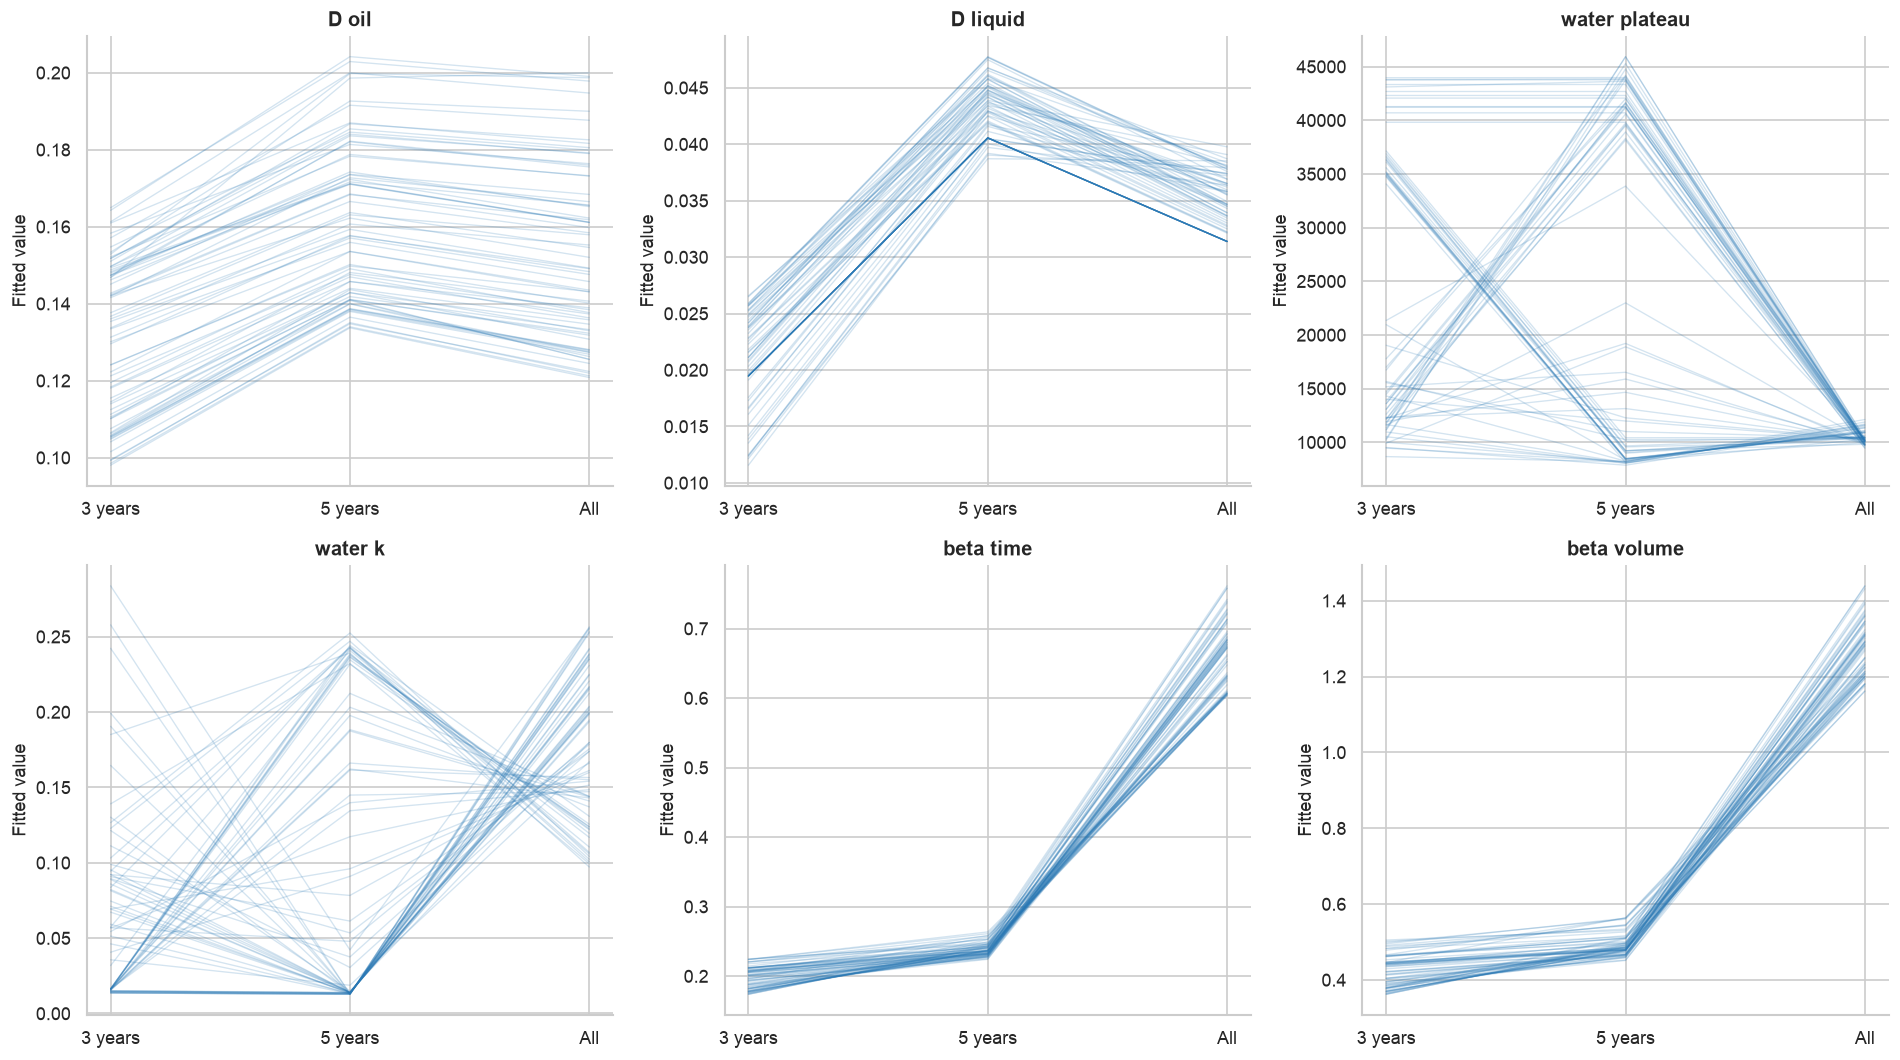

In [4]:
SENSITIVITY_COLUMNS = [
    "D_oil", "D_liquid", "water_plateau",
    "water_k", "beta_time", "beta_volume",
]
train_fits = fits.loc[fits["case_num"] <= 70].copy()

sensitivity_rows = []
for (case, cutoff), group in train_fits.groupby(["case_num", "cutoff"]):
    for column in SENSITIVITY_COLUMNS:
        values = group[column].to_numpy(float)
        median = float(np.median(values))
        sensitivity_rows.append({
            "case_num": case,
            "cutoff": cutoff,
            "parameter": column,
            "minimum": float(values.min()),
            "maximum": float(values.max()),
            "median": median,
            "relative_window_range": float(
                (values.max() - values.min()) / max(abs(median), 1e-6)
            ),
        })

sensitivity = pd.DataFrame(sensitivity_rows)
save_table(
    sensitivity.groupby(["cutoff", "parameter"]).agg(
        median_relative_window_range=("relative_window_range", "median"),
        p90_relative_window_range=(
            "relative_window_range", lambda x: x.quantile(0.9)
        ),
    ).reset_index(),
    "02_window_sensitivity_summary",
)
sensitivity.to_csv(TABLE / "02_window_sensitivity_by_case.csv", index=False)

end_fits = train_fits.loc[
    train_fits["cutoff"] == pd.Timestamp("2008-01-01")
].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, column in zip(axes.flat, SENSITIVITY_COLUMNS):
    wide = end_fits.pivot(index="case_num", columns="window", values=column)
    for _, row in wide.iterrows():
        ax.plot(
            [0, 1, 2], row.reindex(["3y", "5y", "all"]),
            color="#2878B5", alpha=0.20, lw=0.8,
        )
    ax.set_xticks([0, 1, 2], ["3 years", "5 years", "All"])
    ax.set_title(column.replace("_", " "))
    ax.set_ylabel("Fitted value")
show_save(fig, "02_window_sensitivity_2008")

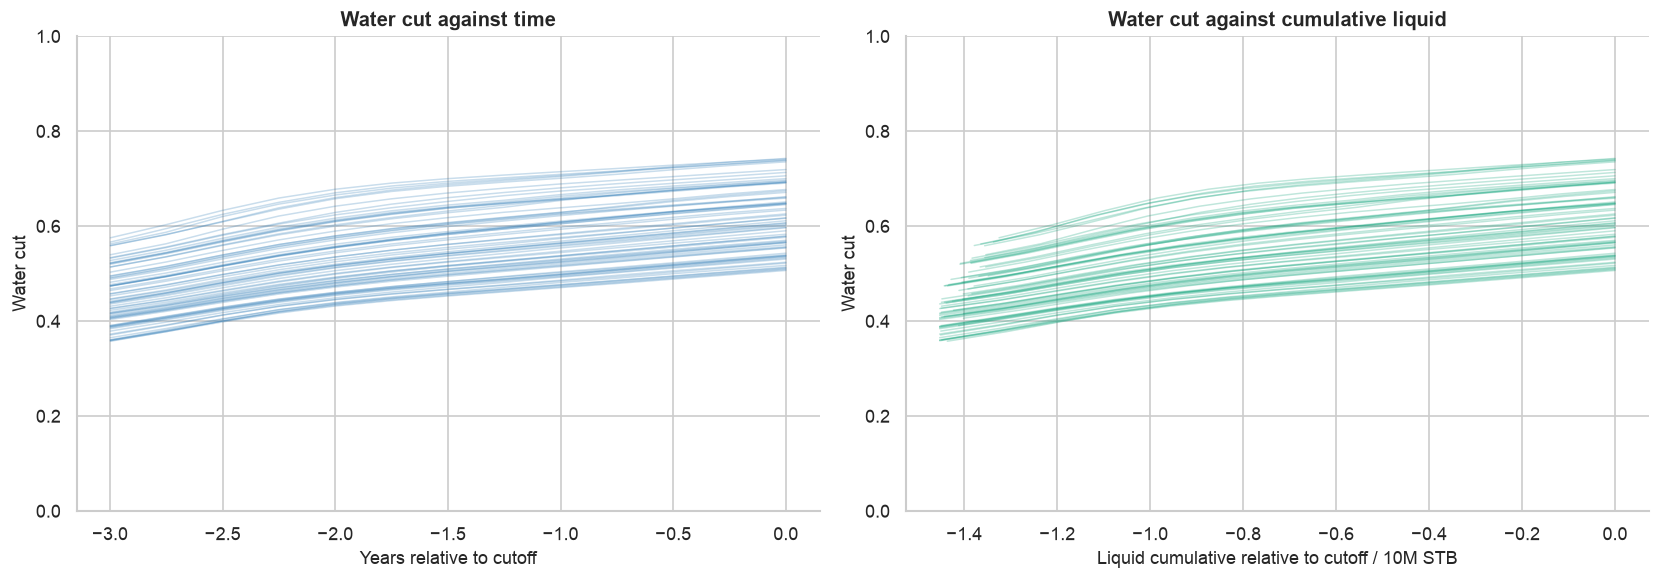

,coordinate,median_WC_RMSE,p90_WC_RMSE
0,Cumulative liquid,0.008470,0.013273
1,Time,0.009017,0.013619


In [5]:
fit_quality_rows = []
end_targets = TRAIN.loc[
    TRAIN["cutoff"] == pd.Timestamp("2008-01-01")
].set_index("case_num")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for case, target in end_targets.iterrows():
    h = history.loc[
        (history["case_num"] == case)
        & (history["cutoff"] == pd.Timestamp("2008-01-01"))
        & (history["date"] >= pd.Timestamp("2005-01-01"))
        & history["water_cut"].notna()
    ].sort_values("date")

    t = (
        (h["date"] - pd.Timestamp("2008-01-01")).dt.total_seconds().to_numpy()
        / (86400 * tu.YEAR_DAYS)
    )
    volume = (
        h["liquid_cum"].to_numpy(float)
        - float(target["anchor_oil"] + target["anchor_water"])
    ) / 1e7

    observed = h["water_cut"].to_numpy(float)
    base = logit(np.clip(target["water_cut"], 1e-6, 1 - 1e-6))
    time_fit = expit(base + target["beta_time"] * t)
    volume_fit = expit(base + target["beta_volume"] * volume)

    for coordinate, prediction in [
        ("Time", time_fit), ("Cumulative liquid", volume_fit)
    ]:
        fit_quality_rows.append({
            "case_num": case,
            "coordinate": coordinate,
            "water_cut_RMSE": float(
                np.sqrt(np.mean((prediction - observed) ** 2))
            ),
        })

    axes[0].plot(t, observed, alpha=0.25, lw=0.9, color="#2878B5")
    axes[1].plot(volume, observed, alpha=0.25, lw=0.9, color="#009E73")

axes[0].set(
    title="Water cut against time",
    xlabel="Years relative to cutoff", ylabel="Water cut", ylim=(0, 1),
)
axes[1].set(
    title="Water cut against cumulative liquid",
    xlabel="Liquid cumulative relative to cutoff / 10M STB",
    ylabel="Water cut", ylim=(0, 1),
)
show_save(fig, "03_water_cut_coordinates")

wc_fit_quality = pd.DataFrame(fit_quality_rows)
save_table(
    wc_fit_quality.groupby("coordinate").agg(
        median_WC_RMSE=("water_cut_RMSE", "median"),
        p90_WC_RMSE=("water_cut_RMSE", lambda x: x.quantile(0.9)),
    ).reset_index(),
    "03_water_cut_coordinate_fit_quality",
)
wc_fit_quality.to_csv(
    TABLE / "03_water_cut_coordinate_fit_quality_by_case.csv", index=False
)

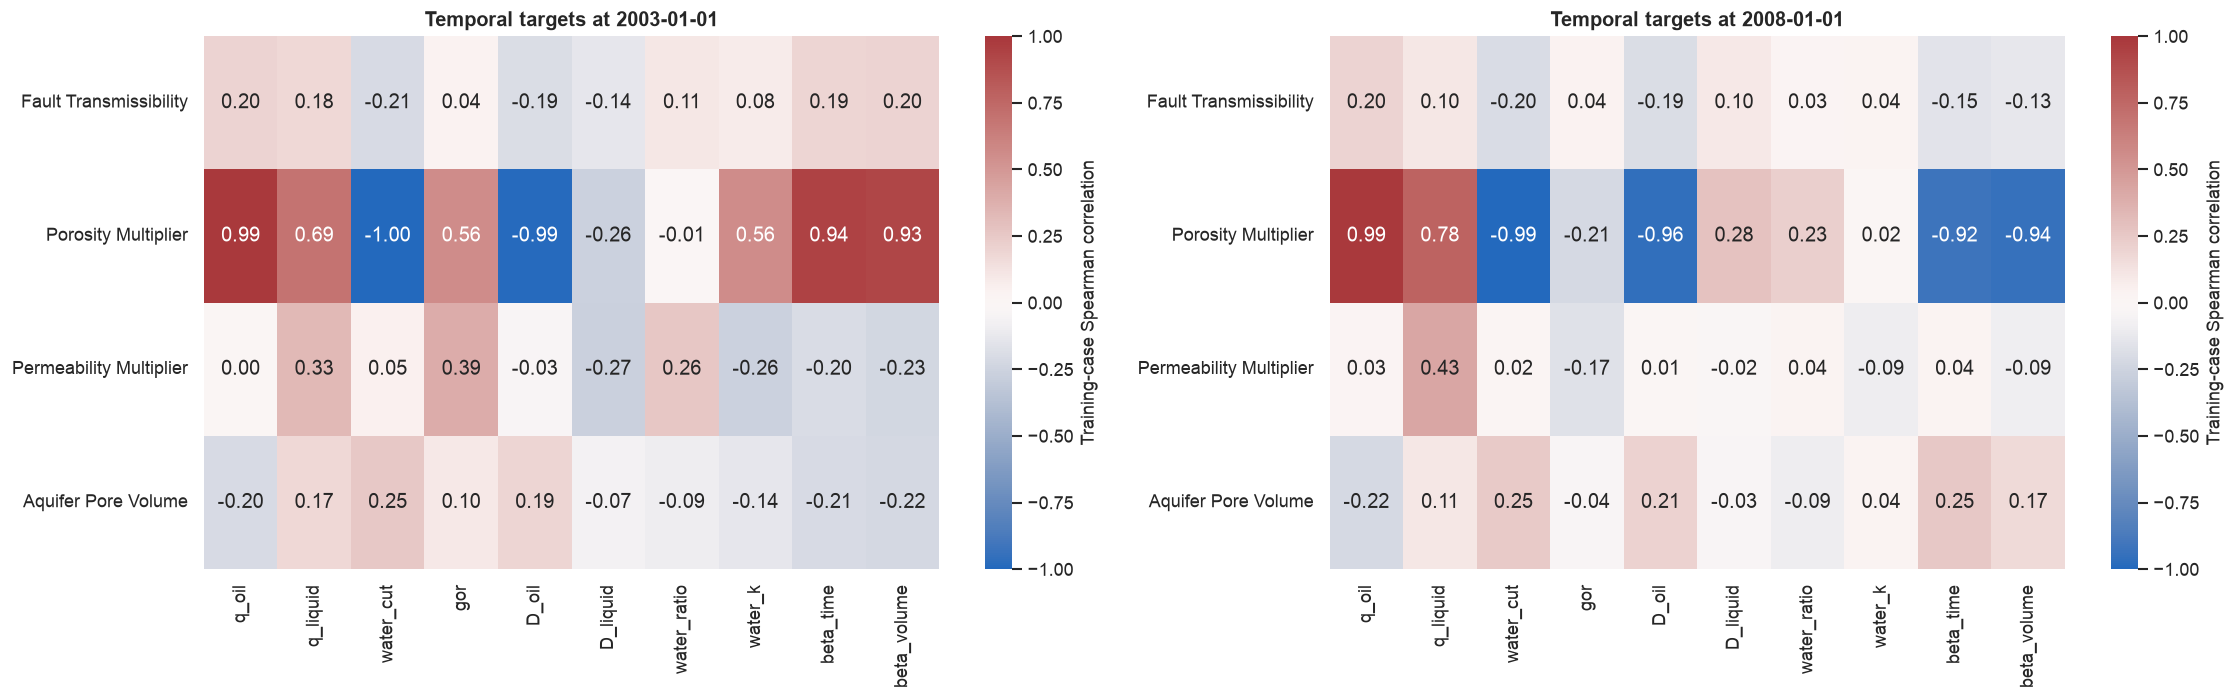

,cutoff,input,target,Spearman_rho
0,2003-01-01,Fault Transmissibility,q_oil,0.197026
1,2003-01-01,Fault Transmissibility,q_liquid,0.177856
2,2003-01-01,Fault Transmissibility,water_cut,-0.208853
3,2003-01-01,Fault Transmissibility,gor,0.044213
4,2003-01-01,Fault Transmissibility,D_oil,-0.191462
...,...,...,...,...
75,2008-01-01,Aquifer Pore Volume,D_liquid,-0.032071
76,2008-01-01,Aquifer Pore Volume,water_ratio,-0.094603
77,2008-01-01,Aquifer Pore Volume,water_k,0.037635
78,2008-01-01,Aquifer Pore Volume,beta_time,0.254868


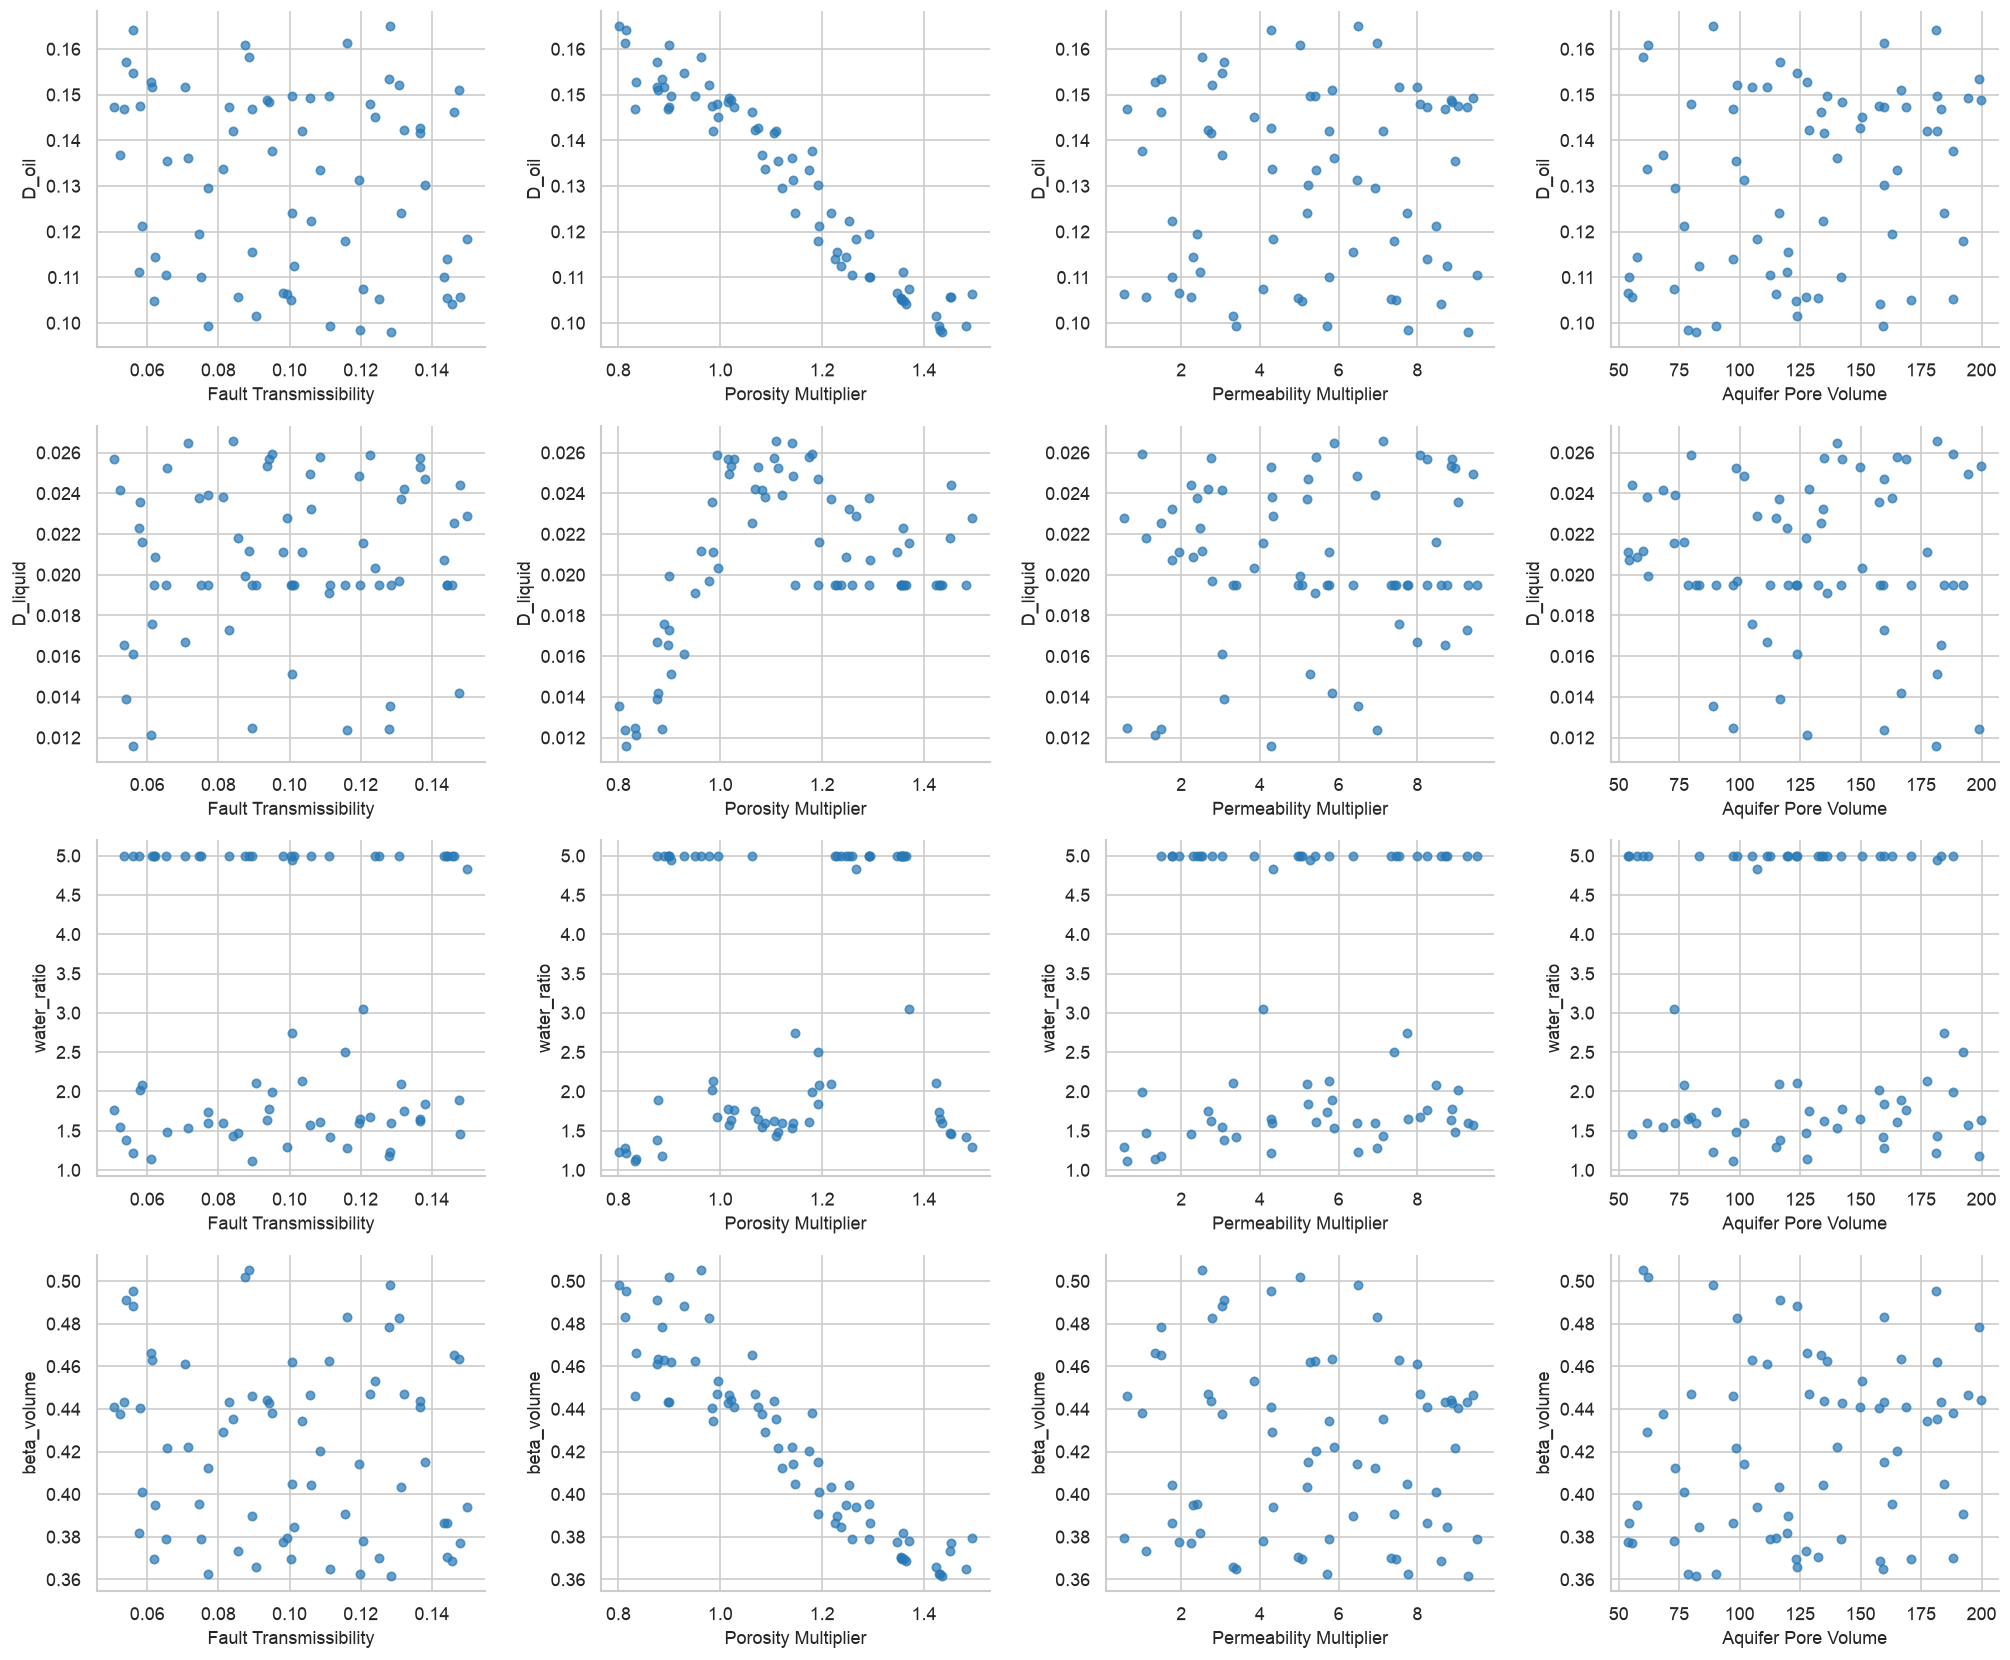

In [6]:
TEMPORAL_COLUMNS = [
    "q_oil", "q_liquid", "water_cut", "gor",
    "D_oil", "D_liquid", "water_ratio",
    "water_k", "beta_time", "beta_volume",
]

correlation_rows = []
fig, axes = plt.subplots(1, 2, figsize=(19, 6))

for ax, origin in zip(
    axes, pd.to_datetime(["2003-01-01", "2008-01-01"])
):
    subset = TRAIN.loc[TRAIN["cutoff"] == origin].merge(
        unc.loc[1:70, PARAMS].reset_index(),
        on="case_num", validate="one_to_one",
    )
    correlation = subset[PARAMS + TEMPORAL_COLUMNS].corr(
        method="spearman"
    ).loc[PARAMS, TEMPORAL_COLUMNS]

    sns.heatmap(
        correlation, annot=True, fmt=".2f",
        vmin=-1, vmax=1, cmap="vlag", ax=ax,
        cbar_kws={"label": "Training-case Spearman correlation"},
    )
    ax.set_title(f"Temporal targets at {origin:%Y-%m-%d}")

    for parameter in PARAMS:
        for target_col in TEMPORAL_COLUMNS:
            correlation_rows.append({
                "cutoff": origin,
                "input": parameter,
                "target": target_col,
                "Spearman_rho": correlation.loc[parameter, target_col],
            })

show_save(fig, "04_inputs_vs_temporal_parameters")
save_table(
    pd.DataFrame(correlation_rows),
    "04_inputs_vs_temporal_parameters",
)

scatter_targets = ["D_oil", "D_liquid", "water_ratio", "beta_volume"]
subset = TRAIN.loc[
    TRAIN["cutoff"] == pd.Timestamp("2008-01-01")
].merge(unc.loc[1:70, PARAMS].reset_index(), on="case_num")

fig, axes = plt.subplots(4, 4, figsize=(17, 14))
for i, target_col in enumerate(scatter_targets):
    for j, parameter in enumerate(PARAMS):
        axes[i, j].scatter(
            subset[parameter], subset[target_col],
            s=25, alpha=0.7, color="#2878B5",
        )
        axes[i, j].set_xlabel(parameter)
        axes[i, j].set_ylabel(target_col)
show_save(fig, "04_temporal_parameter_scatter")

,cutoff,window,kind,median_best_history_NRMSE,median_equivalent_p1_relative_range,p90_equivalent_p1_relative_range,median_jacobian_condition
0,2003-01-01,3y,Arps,0.020320,2.685347e-05,6.583947e-05,6.371186e+15
1,2003-01-01,3y,Water,0.032084,3.360638e-11,2.335846e-10,2.171168e+07
2,2003-01-01,5y,Arps,0.021998,3.835385e-05,1.226953e-04,9.664057e+15
3,2003-01-01,5y,Water,0.114850,1.869056e-11,2.664893e-10,4.095630e+07
4,2003-01-01,all,Arps,0.021998,3.835385e-05,1.226953e-04,9.664057e+15
5,2003-01-01,all,Water,0.114850,1.869056e-11,2.664893e-10,4.095630e+07
6,2008-01-01,3y,Arps,0.016819,1.594245e-07,3.782559e-07,2.657676e+04
7,2008-01-01,3y,Water,0.001719,2.157489e-06,5.316497e-04,2.617540e+07
8,2008-01-01,5y,Arps,0.012410,2.069608e-06,1.529486e-05,6.064637e+04
9,2008-01-01,5y,Water,0.010590,4.651494e-07,5.086194e-06,1.025620e+08


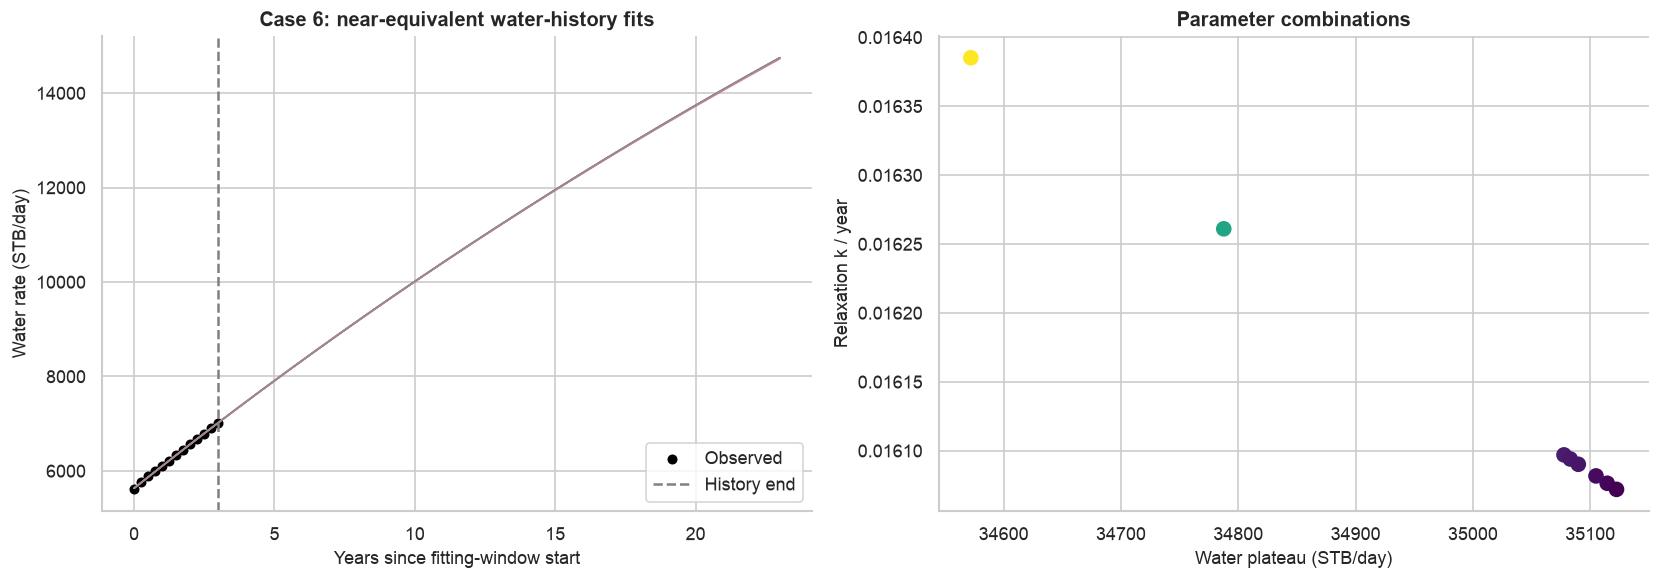

,cutoff,window,median_b,fraction_b_below_001,median_D
0,2003-01-01,3y,1.037624e-07,1.0,0.059797
1,2003-01-01,5y,3.018136e-08,1.0,0.046924
2,2003-01-01,all,3.018136e-08,1.0,0.046924
3,2008-01-01,3y,1.000000e+00,0.0,0.189046
4,2008-01-01,5y,9.492929e-01,0.0,0.278929
5,2008-01-01,all,1.063056e-08,1.0,0.145642


In [7]:
successful_trials = trials.loc[trials["success"]].copy()
equivalence_rows = []

for keys, group in successful_trials.groupby(
    ["case_num", "cutoff", "window", "kind"]
):
    best = float(group["history_NRMSE"].min())
    tolerance = max(0.001, 0.05 * best)
    near = group.loc[group["history_NRMSE"] <= best + tolerance]

    equivalence_rows.append({
        "case_num": keys[0],
        "cutoff": keys[1],
        "window": keys[2],
        "kind": keys[3],
        "best_history_NRMSE": best,
        "near_best_count": len(near),
        "p0_range": float(near["p0"].max() - near["p0"].min()),
        "p1_range": float(near["p1"].max() - near["p1"].min()),
        "p2_range": float(near["p2"].max() - near["p2"].min()),
        "p1_relative_range": float(
            (near["p1"].max() - near["p1"].min())
            / max(abs(float(near["p1"].median())), 1e-6)
        ),
        "median_jacobian_condition": float(
            near["jacobian_condition_number"].median()
        ),
    })

equivalence = pd.DataFrame(equivalence_rows)
save_table(
    equivalence.groupby(["cutoff", "window", "kind"]).agg(
        median_best_history_NRMSE=("best_history_NRMSE", "median"),
        median_equivalent_p1_relative_range=("p1_relative_range", "median"),
        p90_equivalent_p1_relative_range=(
            "p1_relative_range", lambda x: x.quantile(0.9)
        ),
        median_jacobian_condition=("median_jacobian_condition", "median"),
    ).reset_index(),
    "05_identifiability_summary",
)
equivalence.to_csv(TABLE / "05_identifiability_by_case.csv", index=False)

# Visualize worst-identified water case
example = equivalence.loc[
    (equivalence["kind"] == "Water")
    & (equivalence["cutoff"] == pd.Timestamp("2008-01-01"))
    & (equivalence["window"] == "3y")
].sort_values("p1_relative_range", ascending=False).iloc[0]

case = int(example["case_num"])
h = history.loc[
    (history["case_num"] == case)
    & (history["cutoff"] == example["cutoff"])
    & (history["date"] >= example["cutoff"] - pd.DateOffset(years=3))
    & (history["oil_rate"] > 1e-8)
].sort_values("date")

g = successful_trials.loc[
    (successful_trials["case_num"] == case)
    & (successful_trials["cutoff"] == example["cutoff"])
    & (successful_trials["window"] == "3y")
    & (successful_trials["kind"] == "Water")
]
best = g["history_NRMSE"].min()
near = g.loc[g["history_NRMSE"] <= best + max(0.001, 0.05 * best)]

time = np.linspace(0, 23, 400)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for _, row in near.iterrows():
    predicted = row["p1"] + (row["p0"] - row["p1"]) * np.exp(-row["p2"] * time)
    axes[0].plot(time, predicted, alpha=0.65, lw=1.0)

observed_time = (
    (h["date"] - h["date"].iloc[0]).dt.total_seconds().to_numpy()
    / (86400 * tu.YEAR_DAYS)
)
axes[0].scatter(
    observed_time, h["water_rate"], color="black", s=25, label="Observed"
)
axes[0].axvline(3, color="grey", ls="--", label="History end")
axes[0].set(
    title=f"Case {case}: near-equivalent water-history fits",
    xlabel="Years since fitting-window start",
    ylabel="Water rate (STB/day)",
)
axes[0].legend()

axes[1].scatter(
    near["p1"], near["p2"],
    c=near["history_NRMSE"], cmap="viridis", s=70,
)
axes[1].set(
    title="Parameter combinations",
    xlabel="Water plateau (STB/day)", ylabel="Relaxation k / year",
)
show_save(fig, "05_equivalent_history_different_futures")

# Arps b diagnostic
arps_best = successful_trials.loc[
    successful_trials["kind"] == "Arps"
].sort_values("history_NRMSE").drop_duplicates(
    ["case_num", "cutoff", "window"]
)
save_table(
    arps_best.groupby(["cutoff", "window"]).agg(
        median_b=("p2", "median"),
        fraction_b_below_001=("p2", lambda x: float((x < 0.01).mean())),
        median_D=("p1", "median"),
    ).reset_index(),
    "05_arps_b_diagnostic",
)

In [8]:
prediction_parts = []
parameter_error_rows = []

experiments = truth[
    ["cutoff", "horizon_years"]
].drop_duplicates().sort_values(["cutoff", "horizon_years"])

for experiment in experiments.itertuples(index=False):
    origin = pd.Timestamp(experiment.cutoff)
    horizon = int(experiment.horizon_years)

    labels = truth.loc[
        (truth["cutoff"] == origin)
        & (truth["horizon_years"] == horizon)
    ].copy()

    origin_targets = targets.loc[
        targets["cutoff"] == origin
    ].sort_values("case_num").set_index("case_num")

    future_dates = pd.DatetimeIndex(sorted(labels["date"].unique()))

    for method in tu.METHODS:
        input_records = {}

        for fold in range(5):
            hold_cases = folds.index[folds["fold"] == fold].tolist()
            fit_cases = folds.index[folds["fold"] != fold].tolist()

            fit_frame = origin_targets.loc[fit_cases].reset_index()
            estimator, scaler = fit_parameter_map(fit_frame, method)
            records = predict_parameter_map(
                estimator, scaler, hold_cases, method
            )
            input_records.update(dict(zip(hold_cases, records)))

        fit_frame = origin_targets.loc[1:70].reset_index()
        estimator, scaler = fit_parameter_map(fit_frame, method)
        validation_cases = list(range(71, 86))
        records = predict_parameter_map(
            estimator, scaler, validation_cases, method
        )
        input_records.update(dict(zip(validation_cases, records)))

        for case in range(1, 86):
            oracle_record = origin_targets.loc[case].to_dict()
            predicted_record = input_records[case]

            actual_z = tu.encode_targets(
                origin_targets.loc[[case]].reset_index(), method
            )[0]
            predicted_z = tu.encode_targets(
                pd.DataFrame([predicted_record]), method
            )[0]
            for column, actual, predicted in zip(
                tu.HEADS[method], actual_z, predicted_z
            ):
                parameter_error_rows.append({
                    "case_num": case,
                    "cutoff": origin,
                    "horizon_years": horizon,
                    "method": method,
                    "target": column,
                    "transformed_error": float(predicted - actual),
                    "evaluation": (
                        "train_OOF" if case <= 70 else "validation"
                    ),
                })

            for mode, record in [
                ("History-conditioned", oracle_record),
                ("Input-only PolyRidge", predicted_record),
            ]:
                cumulative, rates = tu.forecast(
                    record, method, origin, future_dates
                )
                predicted_anchors = [
                    record["anchor_oil"],
                    record["anchor_gas"],
                    record["anchor_water"],
                ]

                for phase, metric in enumerate(tu.CUM_METRICS):
                    part = labels.loc[
                        (labels["case_num"] == case)
                        & (labels["metric"] == metric)
                    ].sort_values("date").copy()

                    part["prediction"] = cumulative[:, phase]
                    part["predicted_rate"] = rates[:, phase]
                    part["predicted_anchor"] = predicted_anchors[phase]
                    part["predicted_increment"] = (
                        part["prediction"] - part["predicted_anchor"]
                    )
                    part["cumulative_error"] = (
                        part["prediction"] - part["truth"]
                    )
                    part["increment_error"] = (
                        part["predicted_increment"] - part["truth_increment"]
                    )
                    part["anchor_error"] = (
                        part["predicted_anchor"] - part["true_anchor"]
                    )
                    part["method"] = method
                    part["mode"] = mode
                    part["evaluation"] = (
                        "train_OOF" if case <= 70 else "validation"
                    )
                    prediction_parts.append(part)

    print("Backtested:", origin.date(), f"{horizon} years")

backtests = pd.concat(prediction_parts, ignore_index=True)
parameter_errors = pd.DataFrame(parameter_error_rows)

assert np.isfinite(
    backtests[
        ["prediction", "predicted_increment", "increment_error"]
    ].to_numpy(float)
).all()

backtests.to_parquet(DATA / "crossed_backtest_predictions.parquet", index=False)
parameter_errors.to_parquet(
    DATA / "crossed_parameter_prediction_errors.parquet", index=False
)

print("Saved prediction rows:", len(backtests))

Backtested: 2003-01-01 3 years


Backtested: 2003-01-01 5 years


Backtested: 2004-01-01 3 years


Backtested: 2005-01-01 3 years


Saved prediction rows: 114240


,evaluation,cutoff,horizon_years,mode,method,metric,cases,increment_RMSE,increment_NRMSE,cumulative_RMSE,cumulative_NRMSE,anchor_RMSE,increment_bias
0,train_OOF,2003-01-01,3,History-conditioned,Constant,gas_cum,70,7.311806e+05,0.325698,7.311806e+05,0.071368,0.000000,5.732762e+05
1,train_OOF,2003-01-01,3,History-conditioned,Constant,oil_cum,70,2.017130e+06,0.326391,2.017130e+06,0.071515,0.000000,1.582488e+06
2,train_OOF,2003-01-01,3,History-conditioned,Constant,water_cum,70,5.630521e+05,0.141760,5.630521e+05,0.083663,0.000000,-3.884374e+05
3,train_OOF,2003-01-01,3,History-conditioned,Liquid-WC-time,gas_cum,70,2.985977e+05,0.133008,2.985977e+05,0.029145,0.000000,-1.944076e+05
4,train_OOF,2003-01-01,3,History-conditioned,Liquid-WC-time,oil_cum,70,8.225159e+05,0.133091,8.225159e+05,0.029161,0.000000,-5.355230e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,validation,2005-01-01,3,Input-only PolyRidge,Liquid-WC-volume,oil_cum,15,2.520841e+05,0.058582,3.386628e+05,0.010039,143031.473765,-8.425628e+04
188,validation,2005-01-01,3,Input-only PolyRidge,Liquid-WC-volume,water_cum,15,1.906429e+05,0.041856,2.081384e+05,0.018810,27544.607030,-3.472731e+03
189,validation,2005-01-01,3,Input-only PolyRidge,Separate,gas_cum,15,4.867392e+04,0.031140,7.960104e+04,0.006496,50700.994849,1.611962e+04
190,validation,2005-01-01,3,Input-only PolyRidge,Separate,oil_cum,15,1.352449e+05,0.031430,2.231102e+05,0.006613,143031.473765,4.421479e+04


,evaluation,cutoff,horizon_years,mode,method,mean_phase_increment_NRMSE,mean_phase_cumulative_NRMSE
3,train_OOF,2003-01-01,3,History-conditioned,Separate,0.209326,0.071489
0,train_OOF,2003-01-01,3,History-conditioned,Constant,0.264616,0.075515
1,train_OOF,2003-01-01,3,History-conditioned,Liquid-WC-time,0.280599,0.132690
2,train_OOF,2003-01-01,3,History-conditioned,Liquid-WC-volume,0.284626,0.134278
7,train_OOF,2003-01-01,3,Input-only PolyRidge,Separate,0.205303,0.069059
...,...,...,...,...,...,...,...
56,validation,2005-01-01,3,History-conditioned,Constant,0.205581,0.035129
63,validation,2005-01-01,3,Input-only PolyRidge,Separate,0.048853,0.016110
62,validation,2005-01-01,3,Input-only PolyRidge,Liquid-WC-volume,0.052923,0.012924
61,validation,2005-01-01,3,Input-only PolyRidge,Liquid-WC-time,0.072504,0.016037


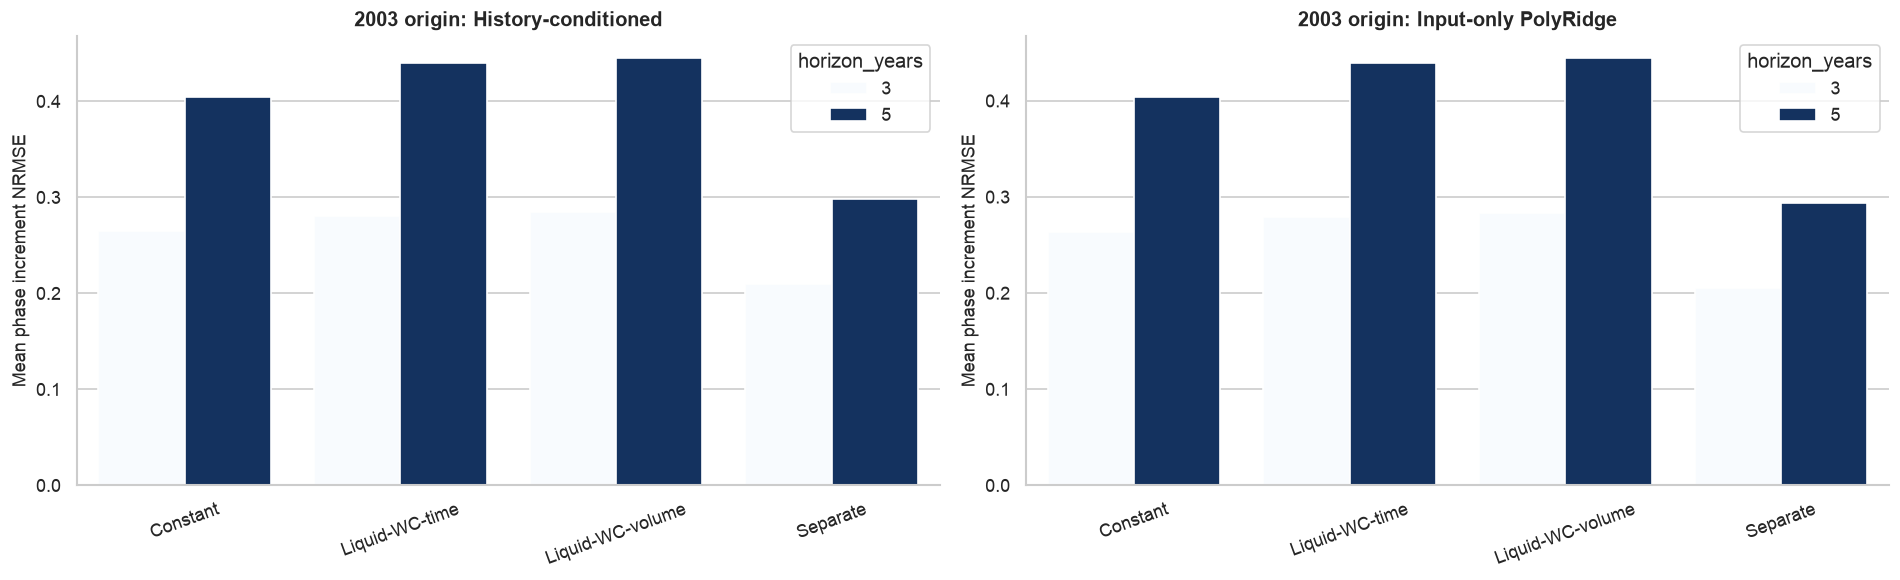

,evaluation,cutoff,horizon_years,mode,metric,alternative,mean_NRMSE_difference,median_NRMSE_difference,fraction_cases_improved
0,train_OOF,2003-01-01,3,History-conditioned,gas_cum,Constant,0.137488,0.129786,0.000000
1,train_OOF,2003-01-01,3,History-conditioned,oil_cum,Constant,0.138394,0.130395,0.000000
2,train_OOF,2003-01-01,3,History-conditioned,water_cum,Constant,-0.015459,-0.041374,0.557143
3,train_OOF,2003-01-01,3,Input-only PolyRidge,gas_cum,Constant,0.136935,0.126606,0.000000
4,train_OOF,2003-01-01,3,Input-only PolyRidge,oil_cum,Constant,0.137900,0.127339,0.000000
...,...,...,...,...,...,...,...,...,...
139,validation,2005-01-01,3,History-conditioned,oil_cum,Liquid-WC-volume,0.019261,0.034223,0.266667
140,validation,2005-01-01,3,History-conditioned,water_cum,Liquid-WC-volume,-0.022198,-0.023503,0.800000
141,validation,2005-01-01,3,Input-only PolyRidge,gas_cum,Liquid-WC-volume,0.021337,0.032309,0.266667
142,validation,2005-01-01,3,Input-only PolyRidge,oil_cum,Liquid-WC-volume,0.021135,0.032236,0.266667


,evaluation,cutoff,method,target,transformed_RMSE
0,train_OOF,2003-01-01,Constant,anchor_gas,0.002154
1,train_OOF,2003-01-01,Constant,anchor_oil,0.002228
2,train_OOF,2003-01-01,Constant,anchor_water,0.009373
3,train_OOF,2003-01-01,Constant,q_gas,0.010931
4,train_OOF,2003-01-01,Constant,q_oil,0.011005
...,...,...,...,...,...
181,validation,2005-01-01,Separate,gor,0.000607
182,validation,2005-01-01,Separate,q_oil,0.012177
183,validation,2005-01-01,Separate,q_water,0.008203
184,validation,2005-01-01,Separate,water_k,0.184960


In [9]:
def summarize_forecasts(frame, group_columns):
    rows = []
    for keys, group in frame.groupby(group_columns, observed=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_columns, keys))

        increment_scale = max(
            float(np.sqrt(np.mean(group["truth_increment"] ** 2))), 1.0
        )
        cumulative_scale = max(
            float(np.sqrt(np.mean(group["truth"] ** 2))), 1.0
        )
        row.update({
            "cases": group["case_num"].nunique(),
            "increment_RMSE": float(
                np.sqrt(np.mean(group["increment_error"] ** 2))
            ),
            "increment_NRMSE": float(
                np.sqrt(np.mean(group["increment_error"] ** 2))
                / increment_scale
            ),
            "cumulative_RMSE": float(
                np.sqrt(np.mean(group["cumulative_error"] ** 2))
            ),
            "cumulative_NRMSE": float(
                np.sqrt(np.mean(group["cumulative_error"] ** 2))
                / cumulative_scale
            ),
            "anchor_RMSE": float(
                np.sqrt(np.mean(group["anchor_error"] ** 2))
            ),
            "increment_bias": float(group["increment_error"].mean()),
        })
        rows.append(row)
    return pd.DataFrame(rows)

GROUPS = [
    "evaluation", "cutoff", "horizon_years", "mode", "method", "metric"
]
phase_scores = summarize_forecasts(backtests, GROUPS)
save_table(phase_scores, "06_crossed_backtest_phase_scores")

macro_scores = phase_scores.groupby(
    GROUPS[:-1], as_index=False
).agg(
    mean_phase_increment_NRMSE=("increment_NRMSE", "mean"),
    mean_phase_cumulative_NRMSE=("cumulative_NRMSE", "mean"),
)
save_table(
    macro_scores.sort_values(
        ["evaluation", "cutoff", "horizon_years",
         "mode", "mean_phase_increment_NRMSE"]
    ),
    "06_crossed_backtest_macro_scores",
)

plot_scores = macro_scores.loc[
    (macro_scores["evaluation"] == "train_OOF")
    & (macro_scores["cutoff"] == pd.Timestamp("2003-01-01"))
].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, mode in zip(
    axes, ["History-conditioned", "Input-only PolyRidge"]
):
    sns.barplot(
        data=plot_scores.loc[plot_scores["mode"] == mode],
        x="method", y="mean_phase_increment_NRMSE",
        hue="horizon_years", ax=ax, palette="Blues",
    )
    ax.set(
        title=f"2003 origin: {mode}",
        xlabel="", ylabel="Mean phase increment NRMSE",
    )
    ax.tick_params(axis="x", rotation=20)
show_save(fig, "06_three_vs_five_year_forecasts")

# Paired decoder comparison
case_scores = summarize_forecasts(
    backtests,
    GROUPS + ["case_num"],
)
pair_index = [
    "evaluation", "cutoff", "horizon_years",
    "mode", "metric", "case_num",
]
paired = case_scores.pivot(
    index=pair_index, columns="method", values="increment_NRMSE"
).reset_index()

paired_rows = []
for alternative in ["Constant", "Liquid-WC-time", "Liquid-WC-volume"]:
    comparison = paired.dropna(subset=["Separate", alternative]).copy()
    comparison["difference_vs_separate"] = (
        comparison[alternative] - comparison["Separate"]
    )
    for keys, group in comparison.groupby(
        ["evaluation", "cutoff", "horizon_years", "mode", "metric"]
    ):
        paired_rows.append({
            **dict(zip(
                ["evaluation", "cutoff", "horizon_years", "mode", "metric"],
                keys,
            )),
            "alternative": alternative,
            "mean_NRMSE_difference": group["difference_vs_separate"].mean(),
            "median_NRMSE_difference": group["difference_vs_separate"].median(),
            "fraction_cases_improved": float(
                (group["difference_vs_separate"] < 0).mean()
            ),
        })

save_table(pd.DataFrame(paired_rows), "06_paired_decoder_comparison")

# Parameter map prediction scores
unique_parameter_errors = parameter_errors.drop_duplicates(
    ["evaluation", "case_num", "cutoff", "method", "target"]
)
parameter_map_scores = unique_parameter_errors.groupby(
    ["evaluation", "cutoff", "method", "target"]
).agg(
    transformed_RMSE=(
        "transformed_error",
        lambda x: float(np.sqrt(np.mean(x ** 2))),
    ),
).reset_index()
save_table(parameter_map_scores, "06_parameter_map_prediction_scores")

,evaluation,cutoff,horizon_years,mode,method,metric,forecast_segment,cases,increment_RMSE,increment_NRMSE,cumulative_RMSE,cumulative_NRMSE,anchor_RMSE,increment_bias
0,train_OOF,2003-01-01,3,History-conditioned,Constant,gas_cum,Early half,70,2.454035e+05,0.185397,2.454035e+05,0.026128,0.000000,1.950380e+05
1,train_OOF,2003-01-01,3,History-conditioned,Constant,gas_cum,Late half,70,1.004503e+06,0.348089,1.004503e+06,0.091050,0.000000,9.515144e+05
2,train_OOF,2003-01-01,3,History-conditioned,Constant,oil_cum,Early half,70,6.781796e+05,0.186138,6.781796e+05,0.026228,0.000000,5.396065e+05
3,train_OOF,2003-01-01,3,History-conditioned,Constant,oil_cum,Late half,70,2.770866e+06,0.348784,2.770866e+06,0.091227,0.000000,2.625370e+06
4,train_OOF,2003-01-01,3,History-conditioned,Constant,water_cum,Early half,70,1.749407e+05,0.087929,1.749407e+05,0.036095,0.000000,-1.169435e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,validation,2005-01-01,3,Input-only PolyRidge,Separate,gas_cum,Late half,15,6.023280e+04,0.029763,9.564894e+04,0.007455,50700.994849,5.214326e+03
380,validation,2005-01-01,3,Input-only PolyRidge,Separate,oil_cum,Early half,15,9.198022e+04,0.037564,1.664656e+05,0.005191,143031.473765,7.421402e+04
381,validation,2005-01-01,3,Input-only PolyRidge,Separate,oil_cum,Late half,15,1.676962e+05,0.030101,2.680402e+05,0.007588,143031.473765,1.421557e+04
382,validation,2005-01-01,3,Input-only PolyRidge,Separate,water_cum,Early half,15,1.146000e+05,0.049631,1.225693e+05,0.013635,27544.607030,-3.059699e+04


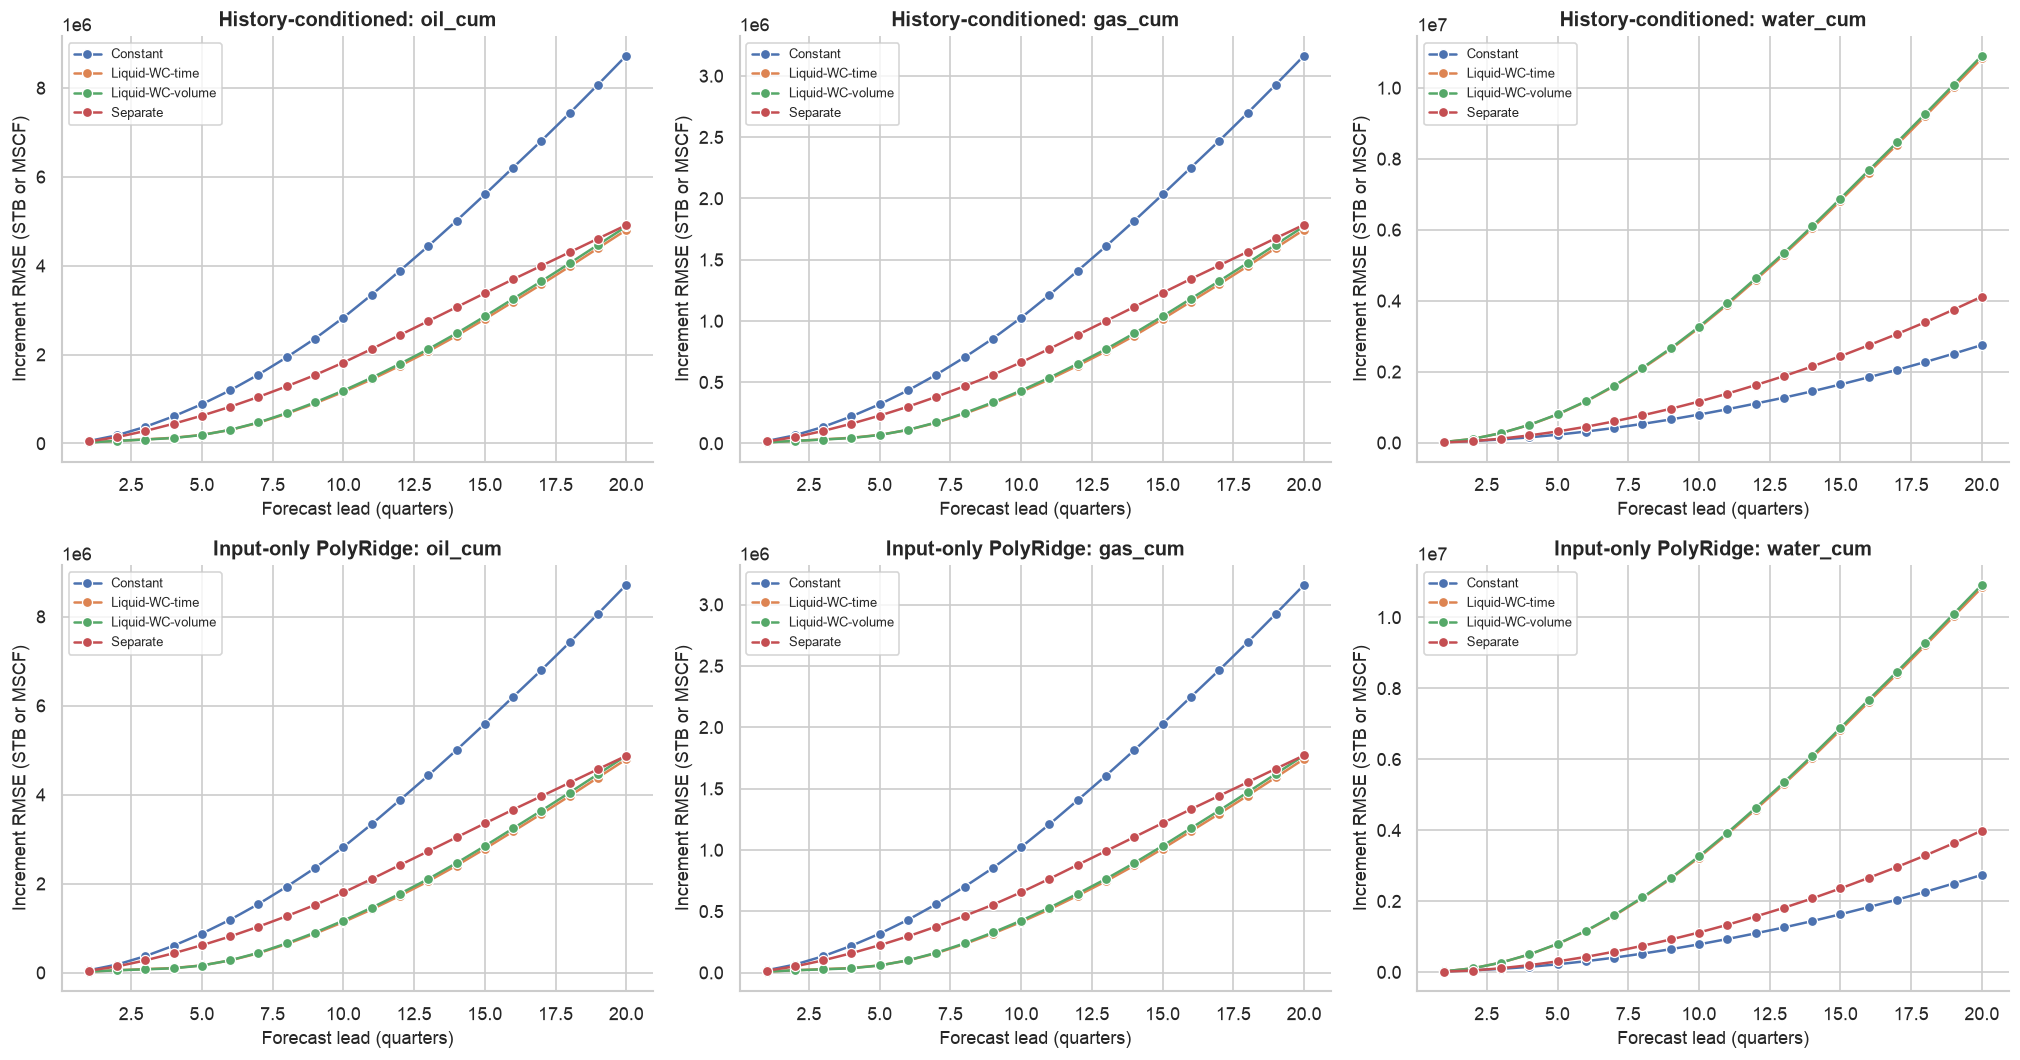

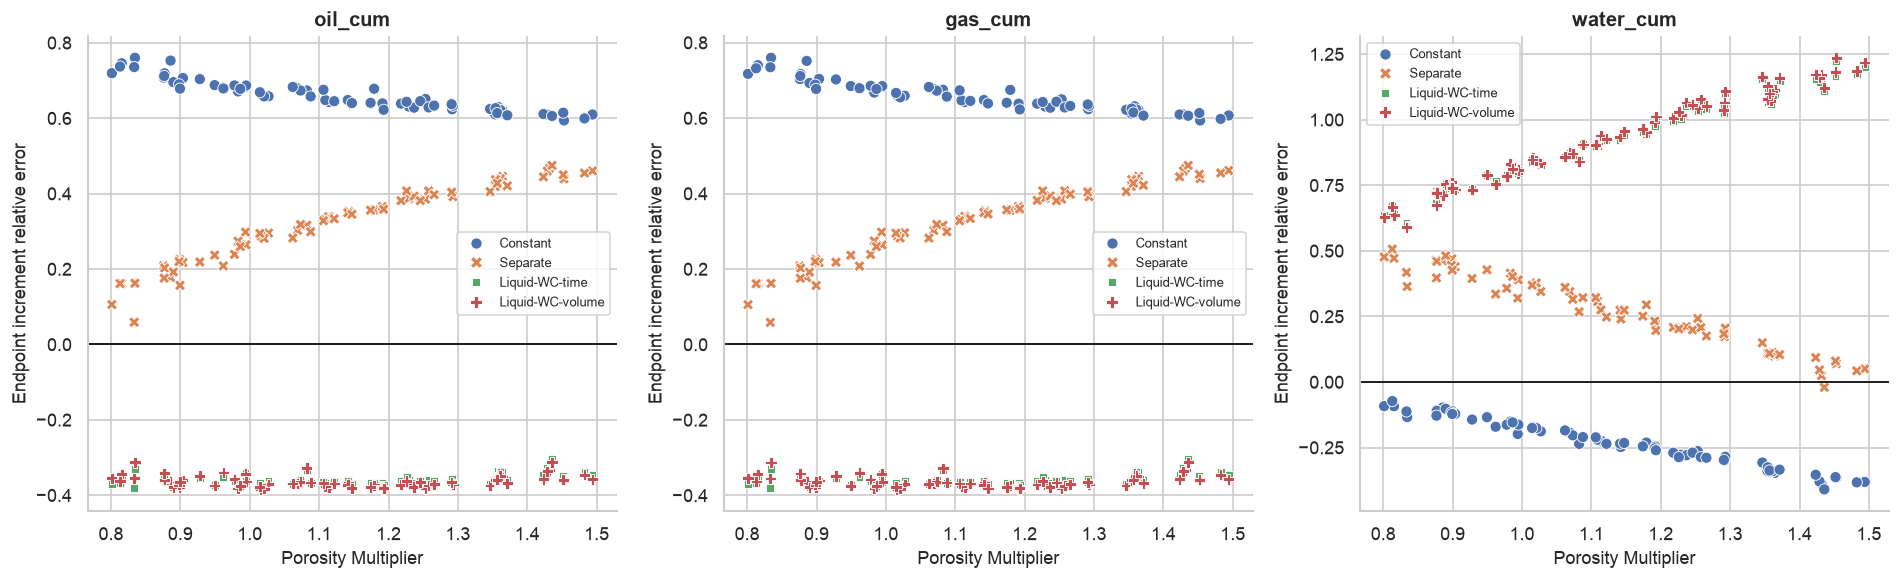

In [10]:
backtests["lead_quarter"] = np.rint(
    backtests["lead_years"] * 4
).astype(int)
backtests["forecast_segment"] = np.where(
    backtests["lead_years"] <= backtests["horizon_years"] / 2,
    "Early half", "Late half",
)

lead_scores = summarize_forecasts(
    backtests,
    [
        "evaluation", "cutoff", "horizon_years",
        "mode", "method", "metric", "lead_quarter",
    ],
)
lead_scores.to_csv(TABLE / "07_errors_by_forecast_lead.csv", index=False)

segment_scores = summarize_forecasts(
    backtests,
    [
        "evaluation", "cutoff", "horizon_years",
        "mode", "method", "metric", "forecast_segment",
    ],
)
save_table(segment_scores, "07_early_vs_late_error")

selected = lead_scores.loc[
    (lead_scores["evaluation"] == "train_OOF")
    & (lead_scores["cutoff"] == pd.Timestamp("2003-01-01"))
    & (lead_scores["horizon_years"] == 5)
]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for i, mode in enumerate(["History-conditioned", "Input-only PolyRidge"]):
    for j, metric in enumerate(tu.CUM_METRICS):
        subset = selected.loc[
            (selected["mode"] == mode) & (selected["metric"] == metric)
        ]
        sns.lineplot(
            data=subset,
            x="lead_quarter", y="increment_RMSE",
            hue="method", ax=axes[i, j], marker="o",
        )
        axes[i, j].set(
            title=f"{mode}: {metric}",
            xlabel="Forecast lead (quarters)",
            ylabel="Increment RMSE (STB or MSCF)",
        )
        axes[i, j].legend(fontsize=8)
show_save(fig, "07_forecast_error_by_lead")

# Endpoint errors vs porosity
endpoint_rows = backtests.loc[
    backtests["lead_quarter"] == backtests["horizon_years"] * 4
].merge(
    unc.loc[1:85, PARAMS].reset_index(),
    on="case_num", validate="many_to_one",
)
endpoint_rows["relative_increment_error"] = (
    endpoint_rows["increment_error"]
    / endpoint_rows["truth_increment"].clip(lower=1)
)
endpoint_rows.to_csv(
    TABLE / "07_endpoint_errors_with_inputs.csv", index=False
)

plot_rows = endpoint_rows.loc[
    (endpoint_rows["evaluation"] == "train_OOF")
    & (endpoint_rows["cutoff"] == pd.Timestamp("2003-01-01"))
    & (endpoint_rows["horizon_years"] == 5)
    & (endpoint_rows["mode"] == "Input-only PolyRidge")
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, tu.CUM_METRICS):
    sns.scatterplot(
        data=plot_rows.loc[plot_rows["metric"] == metric],
        x="Porosity Multiplier", y="relative_increment_error",
        hue="method", style="method", ax=ax, s=45,
    )
    ax.axhline(0, color="black", lw=1)
    ax.set_title(metric)
    ax.set_ylabel("Endpoint increment relative error")
    ax.legend(fontsize=8)
show_save(fig, "07_endpoint_errors_vs_porosity")

In [11]:
HISTORY_DATES = pd.date_range("1998-01-01", "2008-01-01", freq="QS")
HISTORY_METRICS = tu.CUM_METRICS + tu.RATE_METRICS

history_matrix = np.stack([
    np.column_stack([
        tu.interpolate_truth(curves[(case, metric)], HISTORY_DATES)
        for metric in HISTORY_METRICS
    ])
    for case in range(1, 86)
])

def fit_history_surrogate(case_numbers):
    positions = np.asarray(case_numbers, int) - 1
    y = history_matrix[positions]
    pcas = []
    score_parts = []

    for j in range(len(HISTORY_METRICS)):
        pca = PCA(n_components=1, svd_solver="full").fit(y[:, :, j])
        pcas.append(pca)
        score_parts.append(pca.transform(y[:, :, j]))

    z = np.concatenate(score_parts, axis=1)
    scaler = StandardScaler().fit(z)
    model = poly_model().fit(
        unc.loc[list(case_numbers), PARAMS].to_numpy(float),
        scaler.transform(z),
    )
    return model, scaler, pcas

def predict_history_surrogate(bundle, case_numbers):
    model, scaler, pcas = bundle
    z = scaler.inverse_transform(
        model.predict(unc.loc[list(case_numbers), PARAMS].to_numpy(float))
    )
    return np.stack([
        pca.inverse_transform(z[:, j:j + 1])
        for j, pca in enumerate(pcas)
    ], axis=-1)

predicted_history = np.empty_like(history_matrix)

for fold in range(5):
    fit_cases = folds.index[folds["fold"] != fold].tolist()
    hold_cases = folds.index[folds["fold"] == fold].tolist()
    bundle = fit_history_surrogate(fit_cases)
    predicted_history[np.asarray(hold_cases) - 1] = (
        predict_history_surrogate(bundle, hold_cases)
    )

history_bundle = fit_history_surrogate(list(range(1, 71)))
predicted_history[70:85] = predict_history_surrogate(
    history_bundle, list(range(71, 86))
)

historical_score_rows = []
for evaluation, positions in [
    ("train_OOF", np.arange(70)),
    ("validation", np.arange(70, 85)),
]:
    for j, metric in enumerate(HISTORY_METRICS):
        scale = max(
            float(np.sqrt(np.mean(history_matrix[:70, :, j] ** 2))), 1.0
        )
        error = (
            predicted_history[positions, :, j]
            - history_matrix[positions, :, j]
        )
        historical_score_rows.append({
            "evaluation": evaluation,
            "metric": metric,
            "RMSE": float(np.sqrt(np.mean(error ** 2))),
            "training_RMS_normalized_RMSE": float(
                np.sqrt(np.mean(error ** 2)) / scale
            ),
        })
save_table(
    pd.DataFrame(historical_score_rows),
    "08_anas_historical_surrogate_scores",
)

ranking_rows = []
for case in range(1, 86):
    row = {
        "case_num": case,
        "evaluation": "train_OOF" if case <= 70 else "validation",
    }
    phase_scores_list = []
    for j, metric in enumerate(tu.RATE_METRICS, start=3):
        observed = curves.get((0, metric))
        if observed is None or observed.empty:
            print(f"Warning: missing observed history for {metric}, skipping ranking")
            continue

        dates = observed.index[
            (observed.index >= HISTORY_DATES.min())
            & (observed.index <= HISTORY_DATES.max())
        ]
        if len(dates) == 0:
            continue
        actual = observed.loc[dates].to_numpy(float)
        predicted = np.interp(
            dates.asi8.astype(float),
            HISTORY_DATES.asi8.astype(float),
            predicted_history[case - 1, :, j],
        )
        scale = max(float(np.sqrt(np.mean(actual ** 2))), 1.0)
        score = float(np.sqrt(np.mean((predicted - actual) ** 2)) / scale)
        row[metric + "_NRMSE"] = score
        phase_scores_list.append(score)

    if phase_scores_list:
        row["diagnostic_history_match_score"] = float(np.mean(phase_scores_list))
    ranking_rows.append(row)

ranking = pd.DataFrame(ranking_rows).sort_values(
    "diagnostic_history_match_score"
)
save_table(ranking, "08_anas_diagnostic_history_match_ranking")

np.savez_compressed(
    DATA / "anas_historical_predictions.npz",
    case_num=np.arange(1, 86),
    dates=HISTORY_DATES.to_numpy(),
    metric=np.array(HISTORY_METRICS),
    truth=history_matrix,
    prediction=predicted_history,
)

physical_checks = []
for evaluation, positions in [
    ("train_OOF", np.arange(70)),
    ("validation", np.arange(70, 85)),
]:
    cumulative = predicted_history[positions, :, :3]
    rates = predicted_history[positions, :, 3:]
    physical_checks.append({
        "evaluation": evaluation,
        "negative_cumulative_fraction": float((cumulative < -1e-6).mean()),
        "decreasing_cumulative_step_fraction": float(
            (np.diff(cumulative, axis=1) < -1e-6).mean()
        ),
        "negative_rate_fraction": float((rates < -1e-6).mean()),
    })
save_table(pd.DataFrame(physical_checks), "08_historical_physical_checks")

,evaluation,metric,RMSE,training_RMS_normalized_RMSE
0,train_OOF,oil_cum,57039.304222,0.002451
1,train_OOF,gas_cum,20498.346040,0.002425
2,train_OOF,water_cum,54295.456110,0.008058
3,train_OOF,oil_rate,104.626587,0.009798
4,train_OOF,gas_rate,37.569777,0.009687
5,train_OOF,water_rate,107.386227,0.021511
6,validation,oil_cum,89440.421420,0.003843
7,validation,gas_cum,31824.119057,0.003765
8,validation,water_cum,43240.411441,0.006417
9,validation,oil_rate,100.875206,0.009447


,case_num,evaluation,oil_rate_NRMSE,gas_rate_NRMSE,water_rate_NRMSE,diagnostic_history_match_score
80,81,validation,0.213055,0.213074,0.067263,0.164464
44,45,train_OOF,0.213323,0.213358,0.067000,0.164560
68,69,train_OOF,0.213082,0.213095,0.067662,0.164613
23,24,train_OOF,0.213428,0.213440,0.067018,0.164629
64,65,train_OOF,0.213081,0.213094,0.068001,0.164725
...,...,...,...,...,...,...
40,41,train_OOF,0.301436,0.301288,0.352495,0.318406
52,53,train_OOF,0.286705,0.286799,0.382955,0.318820
67,68,train_OOF,0.280359,0.280565,0.404033,0.321652
32,33,train_OOF,0.296095,0.296082,0.374826,0.322335


,evaluation,negative_cumulative_fraction,decreasing_cumulative_step_fraction,negative_rate_fraction
0,train_OOF,0.009059,0.008690,0.007666
1,validation,0.014092,0.012778,0.011924


,case_num,date,method,oil_cum,gas_cum,water_cum,oil_rate,gas_rate,water_rate
79,71,2028-01-01,Constant,8.415987e+07,3.058205e+07,6.089288e+07,6140.372788,2232.207021,6734.204090
159,72,2028-01-01,Constant,8.516730e+07,3.093613e+07,6.087534e+07,6281.101097,2281.042740,6734.039446
239,73,2028-01-01,Constant,8.104673e+07,2.944543e+07,6.337672e+07,5828.657902,2118.309775,6964.751286
319,74,2028-01-01,Constant,8.318789e+07,3.022107e+07,6.155496e+07,6050.828800,2198.660360,6778.741898
399,75,2028-01-01,Constant,7.061566e+07,2.564341e+07,7.325025e+07,4787.684374,1738.247730,7931.987494
479,76,2028-01-01,Constant,8.123800e+07,2.951229e+07,6.353588e+07,5835.015541,2120.035036,6989.450703
559,77,2028-01-01,Constant,7.298860e+07,2.650456e+07,7.104094e+07,5019.806772,1822.330911,7724.471253
639,78,2028-01-01,Constant,7.186239e+07,2.609832e+07,7.198497e+07,4915.750060,1785.000319,7806.725798
719,79,2028-01-01,Constant,7.723126e+07,2.804954e+07,6.857668e+07,5459.114257,1982.319160,7486.225888
799,80,2028-01-01,Constant,5.943378e+07,2.158766e+07,7.921074e+07,3720.550920,1351.400069,8490.565179


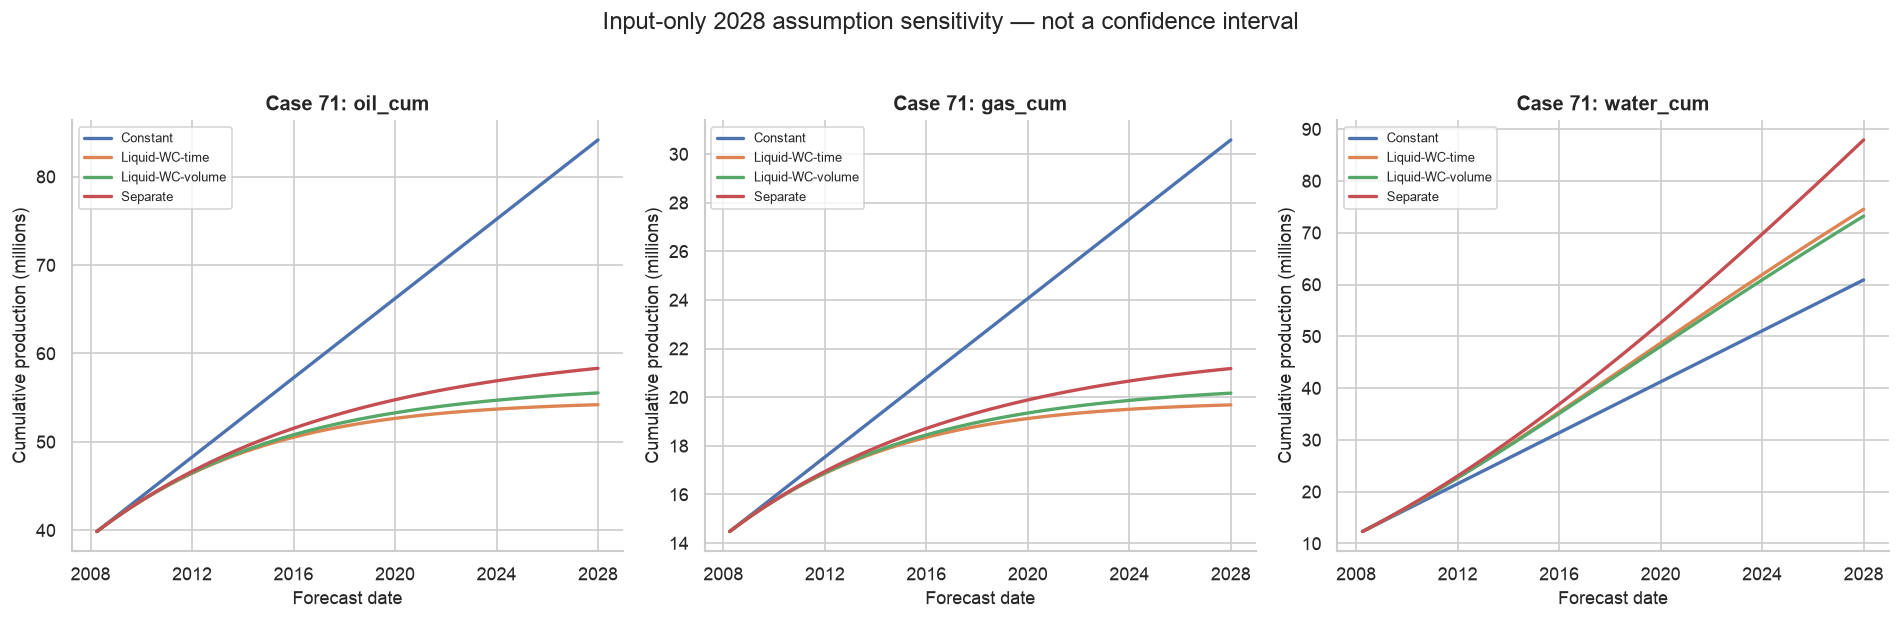

,case_num,metric,minimum_2028,maximum_2028,spread_relative_to_minimum
0,71,oil_cum,5.420229e+07,8.415987e+07,0.552699
1,71,gas_cum,1.968398e+07,3.058205e+07,0.553652
2,71,water_cum,6.089288e+07,8.791744e+07,0.443805
3,72,oil_cum,5.475238e+07,8.516730e+07,0.555500
4,72,gas_cum,1.989214e+07,3.093613e+07,0.555193
5,72,water_cum,6.087534e+07,9.153164e+07,0.503592
6,73,oil_cum,5.173174e+07,8.104673e+07,0.566673
7,73,gas_cum,1.878717e+07,2.944543e+07,0.567316
8,73,water_cum,6.337672e+07,9.162235e+07,0.445678
9,74,oil_cum,5.307781e+07,8.318789e+07,0.567282


In [12]:
FUTURE_DATES = pd.date_range("2008-04-01", "2028-01-01", freq="QS")
end_targets = targets.loc[
    targets["cutoff"] == pd.Timestamp("2008-01-01")
].set_index("case_num")

scenario_parts = []

for method in tu.METHODS:
    estimator, scaler = fit_parameter_map(
        end_targets.loc[1:70].reset_index(), method
    )
    cases = list(range(71, 86))
    records = predict_parameter_map(estimator, scaler, cases, method)

    for case, record in zip(cases, records):
        cumulative, rates = tu.forecast(
            record, method, pd.Timestamp("2008-01-01"), FUTURE_DATES
        )
        anchors = np.array([
            record["anchor_oil"], record["anchor_gas"], record["anchor_water"]
        ])
        assert (cumulative >= anchors[None, :] - 1e-6).all()
        assert (np.diff(cumulative, axis=0) >= -1e-6).all()

        scenario_parts.append(pd.DataFrame({
            "case_num": case,
            "date": FUTURE_DATES,
            "method": method,
            "oil_cum": cumulative[:, 0],
            "gas_cum": cumulative[:, 1],
            "water_cum": cumulative[:, 2],
            "oil_rate": rates[:, 0],
            "gas_rate": rates[:, 1],
            "water_rate": rates[:, 2],
        }))

scenarios = pd.concat(scenario_parts, ignore_index=True)
scenarios.to_parquet(DATA / "conditional_2028_scenarios.parquet", index=False)

endpoints = scenarios.loc[
    scenarios["date"] == FUTURE_DATES[-1]
].copy()
save_table(endpoints, "09_conditional_2028_endpoints")

example_case = 71
example = scenarios.loc[scenarios["case_num"] == example_case]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, tu.CUM_METRICS):
    for method, group in example.groupby("method"):
        ax.plot(
            group["date"], group[metric] / 1e6,
            label=method, lw=2,
        )
    ax.set(
        title=f"Case {example_case}: {metric}",
        xlabel="Forecast date", ylabel="Cumulative production (millions)",
    )
    ax.legend(fontsize=8)
fig.suptitle(
    "Input-only 2028 assumption sensitivity \u2014 not a confidence interval",
    y=1.03,
)
show_save(fig, "09_conditional_2028_scenarios")

spread_rows = []
for case, group in endpoints.groupby("case_num"):
    for metric in tu.CUM_METRICS:
        minimum = float(group[metric].min())
        maximum = float(group[metric].max())
        spread_rows.append({
            "case_num": case,
            "metric": metric,
            "minimum_2028": minimum,
            "maximum_2028": maximum,
            "spread_relative_to_minimum": (
                (maximum - minimum) / max(minimum, 1.0)
            ),
        })
save_table(pd.DataFrame(spread_rows), "09_2028_structural_spread")

In [13]:
warning_scores = macro_scores.copy()
warning_scores["review_required_over_020"] = (
    warning_scores["mean_phase_increment_NRMSE"] > 0.20
)
save_table(warning_scores, "10_forecast_review_flags")

training_input_scores = macro_scores.loc[
    (macro_scores["evaluation"] == "train_OOF")
    & (macro_scores["mode"] == "Input-only PolyRidge")
]

recommendation = training_input_scores.groupby(
    "method", as_index=False
).agg(
    mean_development_increment_NRMSE=("mean_phase_increment_NRMSE", "mean"),
    worst_experiment_increment_NRMSE=("mean_phase_increment_NRMSE", "max"),
).sort_values("mean_development_increment_NRMSE")

save_table(recommendation, "10_development_decoder_ranking")

best_development_method = recommendation.iloc[0]["method"]

handoff = f"""# Anas Temporal Validation Handoff

## Scope
- Training: Cases 1-70, fixed five-fold held-case OOF predictions.
- Validation: Cases 71-85, parameter maps fitted on Cases 1-70.
- Test production labels: not loaded.
- Origins: 2003, 2004, 2005.
- Horizons: fixed three-year comparisons plus a five-year 2003-origin comparison.
- Default target extraction: three-year pre-cutoff fitting window.

## Pipeline
- Four uncertainty inputs.
- One-PC historical cumulative/rate heads with Polynomial Ridge.
- Transformed temporal-parameter heads with Polynomial Ridge.
- Positive-rate decoder and cumulative integration from predicted anchors.

## Development ranking
Best mean input-only training-OOF decoder: {best_development_method}

This is a development ranking, not proof of superiority at 2028.
Check phase scores, paired case comparisons, late-horizon errors,
parameter-map errors, and fitting-window sensitivity before locking a decoder.

## Essential Distinctions
1. History-conditioned forecasts isolate temporal extrapolation error.
2. Input-only forecasts include geological mapping error.
3. Cumulative error includes anchor error.
4. Increment error isolates predicted future growth.
5. Twenty-year scenario spread is structural disagreement, not a calibrated interval.

## Constraints and Assumptions
- Nonnegative production rates.
- Nondecreasing cumulative production.
- Liquid exponential candidates assume nonincreasing liquid production.
- Logistic water-cut candidates assume nondecreasing water cut.
- No arbitrary 96% water-cut cap.
- GOR remains fixed at its cutoff-history estimate.
- Future injection and operating controls are unknown.

## Required Review
- tables/06_crossed_backtest_macro_scores.csv
- tables/06_crossed_backtest_phase_scores.csv
- tables/06_paired_decoder_comparison.csv
- tables/07_early_vs_late_error.csv
- tables/02_window_sensitivity_summary.csv
- tables/05_identifiability_summary.csv
- tables/10_forecast_review_flags.csv

## Limits
No future simulator labels exist beyond 2008 in the supplied project.
A successful 3-5-year backtest does not validate a 20-year forecast.
The 0.20 warning threshold is a team review trigger, not an official criterion.
Do not report scenario envelopes as P10/P50/P90 calibrated forecast uncertainty.

## Next Step
Lock the temporal specification, transformations, fitting window, and model
hyperparameters before the team's one-time Cases 86-100 evaluation.
If tuning is added, use inner case folds and retain outer case folds for
honest development evaluation.
"""

(OUT / "TEMPORAL_VALIDATION_HANDOFF.md").write_text(
    handoff, encoding="utf-8"
)
print(handoff)

,evaluation,cutoff,horizon_years,mode,method,mean_phase_increment_NRMSE,mean_phase_cumulative_NRMSE,review_required_over_020
0,train_OOF,2003-01-01,3,History-conditioned,Constant,0.264616,0.075515,True
1,train_OOF,2003-01-01,3,History-conditioned,Liquid-WC-time,0.280599,0.132690,True
2,train_OOF,2003-01-01,3,History-conditioned,Liquid-WC-volume,0.284626,0.134278,True
3,train_OOF,2003-01-01,3,History-conditioned,Separate,0.209326,0.071489,True
4,train_OOF,2003-01-01,3,Input-only PolyRidge,Constant,0.263351,0.074860,True
...,...,...,...,...,...,...,...,...
59,validation,2005-01-01,3,History-conditioned,Separate,0.042165,0.011364,False
60,validation,2005-01-01,3,Input-only PolyRidge,Constant,0.202782,0.034438,True
61,validation,2005-01-01,3,Input-only PolyRidge,Liquid-WC-time,0.072504,0.016037,False
62,validation,2005-01-01,3,Input-only PolyRidge,Liquid-WC-volume,0.052923,0.012924,False


,method,mean_development_increment_NRMSE,worst_experiment_increment_NRMSE
3,Separate,0.154816,0.293494
2,Liquid-WC-volume,0.211681,0.444831
1,Liquid-WC-time,0.221037,0.439232
0,Constant,0.275565,0.403678


# Anas Temporal Validation Handoff

## Scope
- Training: Cases 1-70, fixed five-fold held-case OOF predictions.
- Validation: Cases 71-85, parameter maps fitted on Cases 1-70.
- Test production labels: not loaded.
- Origins: 2003, 2004, 2005.
- Horizons: fixed three-year comparisons plus a five-year 2003-origin comparison.
- Default target extraction: three-year pre-cutoff fitting window.

## Pipeline
- Four uncertainty inputs.
- One-PC historical cumulative/rate heads with Polynomial Ridge.
- Transformed temporal-parameter heads with Polynomial Ridge.
- Positive-rate decoder and cumulative integration from predicted anchors.

## Development ranking
Best mean input-only training-OOF decoder: Separate

This is a development ranking, not proof of superiority at 2028.
Check phase scores, paired case comparisons, late-horizon errors,
parameter-map errors, and fitting-window sensitivity before locking a decoder.

## Essential Distinctions
1. History-conditioned forecasts isolate temporal ex